# CS3807 — Deep Learning Laboratory Experiment 5 : Comprehensive Study of CNN Training, Regularization, Optimization, Hyperparameter Tuning, Transfer Learning and Cross-Validation

## 0. Setup

In [9]:

# ---- 0a. Install pinned dependencies (avoid version conflicts) ----
!pip install -q scikit-learn==1.5.2 scikeras==0.13.0 --upgrade


In [10]:
# ---- 0b. Imports ----
import os, io, json, time, random, shutil, zipfile, warnings

# Redirect the OS-level stderr file descriptor to devnull for the ENTIRE notebook run.
# This is necessary because TF's C++ runtime (GPU device creation logs, CUDA timer warnings)
# and libjpeg (corrupt JPEG messages) write directly to the process's stderr fd, bypassing
# Python's logging/warnings system and env vars like TF_CPP_MIN_LOG_LEVEL entirely.
# NOTE: this also hides genuine Python tracebacks that print to stderr. If a cell appears to
# silently fail with no error shown, temporarily comment out the two lines below to debug.
import sys
_stderr_fd_backup = os.dup(sys.stderr.fileno())
_devnull_fd = os.open(os.devnull, os.O_WRONLY)
os.dup2(_devnull_fd, sys.stderr.fileno())

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

import tensorflow as tf
tf.get_logger().setLevel("ERROR")
tf.autograph.set_verbosity(0)
try:
    import absl.logging
    absl.logging.set_verbosity(absl.logging.ERROR)
except ImportError:
    pass

from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [11]:

# ---- 0c. Global plotting style: Times New Roman 13, bold axes, 150 DPI, saved to outputs/figures ----

# Corrupt JPEG warnings ("extraneous bytes before marker", "premature end of data segment") are
# printed directly to the process's stderr file descriptor by the underlying libjpeg C library
# during tf.image.decode_jpeg -- they bypass Python's logging/warnings system entirely, so
# TF_CPP_MIN_LOG_LEVEL alone does not silence them.
#
# NOTE: redirecting the raw OS stderr fd would also hide genuine Python tracebacks/errors printed
# to stderr for the rest of the notebook, which is a bad trade-off for a lab exercise where you
# want to see real failures. Instead we suppress these specific warnings a safer way: pass
# try_recover_truncated=True to decode_jpeg (already handled in decode_and_resize below) so
# decoding recovers cleanly, and simply accept that a small number of these one-line libjpeg
# messages may still print for a handful of known-malformed images in this dataset -- they do
# not affect correctness, they can be ignored.

FIG_DIR = "outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Try to register a Times New Roman-like font (Colab/Linux usually lacks true Times New Roman,
# so we fetch/liberation "Liberation Serif" as a metric-compatible substitute if TNF is unavailable).
def ensure_times_new_roman():
    candidates = [f.name for f in font_manager.fontManager.ttflist]
    if "Times New Roman" in candidates:
        return "Times New Roman"
    if "Liberation Serif" in candidates:
        return "Liberation Serif"
    # Attempt install of liberation-fonts (metric-compatible with Times New Roman)
    os.system("apt-get -qq install -y fonts-liberation2 > /dev/null 2>&1")
    font_manager._load_fontmanager(try_read_cache=False)
    candidates = [f.name for f in font_manager.fontManager.ttflist]
    for name in ["Times New Roman", "Liberation Serif", "DejaVu Serif"]:
        if name in candidates:
            return name
    return "serif"

FONT_NAME = ensure_times_new_roman()
print("Using font:", FONT_NAME)

mpl.rcParams['font.family'] = FONT_NAME
mpl.rcParams['font.size'] = 13
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['xtick.labelsize'] = 13
mpl.rcParams['ytick.labelsize'] = 13
mpl.rcParams['legend.fontsize'] = 13
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['savefig.dpi'] = 150

def style_axes(ax):
    """Bold x & y axis labels + bold tick labels, Times New Roman 13 throughout."""
    ax.set_xlabel(ax.get_xlabel(), fontweight='bold', fontsize=13, fontname=FONT_NAME)
    ax.set_ylabel(ax.get_ylabel(), fontweight='bold', fontsize=13, fontname=FONT_NAME)
    if ax.get_title():
        ax.set_title(ax.get_title(), fontweight='bold', fontsize=13, fontname=FONT_NAME)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')
        lbl.set_fontname(FONT_NAME)
        lbl.set_fontsize(13)
    if ax.get_legend():
        for text in ax.get_legend().get_texts():
            text.set_fontname(FONT_NAME)
            text.set_fontsize(13)

def savefig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=150, format='png', bbox_inches='tight')
    print("Saved:", path)
    plt.show()


Using font: Liberation Serif


In [12]:

# ---- 0d. Dataset location (running natively in Kaggle -- dataset is already mounted, no download needed) ----
# Update DATA_ROOT below to match the exact path shown under "Input" in your Kaggle notebook
# for the Oxford-IIIT Pet Dataset (e.g. /kaggle/input/the-oxfordiiit-pet-dataset).
DATA_ROOT = "/kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images"

if not os.path.exists(DATA_ROOT):
    raise FileNotFoundError(
        f"DATA_ROOT not found at {DATA_ROOT}. "
        "Update DATA_ROOT to the exact path of the dataset as added under Kaggle 'Input' "
        "(check the left sidebar of your Kaggle notebook for the correct folder name)."
    )

# Locate the images directory (dataset layout: images/<breed>_<num>.jpg)
IMG_DIR = None
for root, dirs, fs in os.walk(DATA_ROOT):
    if any(f.lower().endswith((".jpg", ".jpeg", ".png")) for f in fs):
        IMG_DIR = root
        break
print("Image directory found at:", IMG_DIR)
print("Number of images:", len([f for f in os.listdir(IMG_DIR) if f.lower().endswith((".jpg",".jpeg",".png"))]))


Image directory found at: /kaggle/input/datasets/tanlikesmath/the-oxfordiiit-pet-dataset/images
Number of images: 7390


In [13]:

# ---- 0f. Build dataframe (filepath, breed label, binary species label) & train/val/test split ----
IMG_SIZE = (224, 224)

files_list = [f for f in os.listdir(IMG_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

def parse_breed(fname):
    # Oxford-IIIT Pet filenames: <breed_name>_<index>.jpg  (breed may itself contain underscores)
    stem = os.path.splitext(fname)[0]
    parts = stem.split("_")
    breed = "_".join(parts[:-1])
    return breed

records = []
for f in files_list:
    breed = parse_breed(f)
    # Cats: breed name starts with an uppercase letter in this dataset's convention; Dogs: lowercase.
    species = "cat" if breed[:1].isupper() else "dog"
    records.append({"filepath": os.path.join(IMG_DIR, f), "breed": breed, "species": species})

df = pd.DataFrame(records)
print("Total images:", len(df))
print(df['species'].value_counts())
print("Number of breeds (classes):", df['breed'].nunique())

# We use the 37-breed classification task (primary task described in the manual: "37 breeds").
CLASS_NAMES = sorted(df['breed'].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
df['label'] = df['breed'].map(class_to_idx)

# Train / Val / Test split: 70 / 15 / 15, stratified on breed. Test set held out from ALL tuning.
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df['label'], random_state=SEED)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
train_df.to_csv("outputs/train_split.csv", index=False)
val_df.to_csv("outputs/val_split.csv", index=False)
test_df.to_csv("outputs/test_split.csv", index=False)


Total images: 7390
species
dog    4990
cat    2400
Name: count, dtype: int64
Number of breeds (classes): 37
Train: 5173 Val: 1108 Test: 1109


In [14]:

# ---- 0g. tf.data pipeline builder (reusable across all experiments) ----
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE_DEFAULT = 32

def decode_and_resize(path, label):
    """Decode + resize only (no augmentation, no normalization) -- this is the expensive,
    disk/CPU-bound part, so it is what we cache. Cached ONCE per dataset on first epoch;
    every subsequent epoch reads straight from the cache instead of re-decoding JPEGs.
    try_recover_truncated=True lets the decoder recover partial/corrupt JPEGs (a handful exist
    in the Oxford-IIIT Pet dataset itself) instead of failing on them."""
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3, try_recover_truncated=True, acceptable_fraction=0.5)
    img = tf.image.resize(img, IMG_SIZE)
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label

def augment_and_normalize(img, label, augment=False):
    """Cheap, per-epoch-varying ops -- applied AFTER the cache so augmentation still differs
    every epoch, and MobileNetV2 preprocessing is applied last."""
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
    img = preprocess_input(img)
    return img, label

def make_dataset(dframe, batch_size=BATCH_SIZE_DEFAULT, shuffle=False, augment=False, cache=True, cache_path=""):
    paths = dframe['filepath'].values
    labels = dframe['label'].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    if cache:
        # Disk-backed cache (NOT in-memory): passing a file path instead of no argument writes
        # the decoded+resized tensors to disk on first epoch and reads from disk afterwards.
        # This avoids RAM blowups on Colab (T4 instances have limited system RAM), while still
        # skipping the expensive JPEG decode+resize on every epoch after the first.
        # Only use this for datasets that are REUSED across many epochs/runs (train_ds/val_ds/test_ds
        # built once in Setup). Do NOT cache one-off datasets built inside loops (e.g. K-Fold folds,
        # per-batch-size sweeps) -- each is used briefly and never revisited, so caching them just
        # accumulates disk/RAM pressure with folds that are dropped anyway. In those cases call this
        # with cache=False.
        os.makedirs("/kaggle/working/cache", exist_ok=True)
        ds = ds.cache(cache_path if cache_path else "")
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dframe), seed=SEED)
    ds = ds.map(lambda img, l: augment_and_normalize(img, l, augment=augment), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

# Clear any stale cache files from a previous run before building the main datasets
shutil.rmtree("/kaggle/working/cache", ignore_errors=True)
os.makedirs("/kaggle/working/cache", exist_ok=True)

train_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True, cache_path="/kaggle/working/cache/train")
val_ds   = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val")
test_ds  = make_dataset(test_df, cache=True, cache_path="/kaggle/working/cache/test")

print("Datasets built. train_ds/val_ds/test_ds are disk-cached (not in-memory) to avoid RAM crashes.")
print("Datasets built inside loops later (K-Fold folds, batch-size sweeps) will NOT be cached -- this is intentional.")
print("Steps/epoch (train):", len(train_df)//BATCH_SIZE_DEFAULT)
print("Note: the first epoch of any run will be slower while the cache warms up; subsequent epochs are much faster.")


Datasets built. train_ds/val_ds/test_ds are disk-cached (not in-memory) to avoid RAM crashes.
Datasets built inside loops later (K-Fold folds, batch-size sweeps) will NOT be cached -- this is intentional.
Steps/epoch (train): 161
Note: the first epoch of any run will be slower while the cache warms up; subsequent epochs are much faster.


In [15]:

# ---- 0h. Model builder helper: MobileNetV2 base + custom classifier head ----
def build_mobilenetv2_model(num_classes=NUM_CLASSES,
                             trainable_base=False,
                             unfreeze_from=None,
                             dropout_rate=0.5,
                             use_batchnorm=True,
                             l2_reg=0.0,
                             kernel_initializer="glorot_uniform",
                             weights="imagenet"):
    base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights=weights)
    base_model.trainable = trainable_base
    if trainable_base and unfreeze_from is not None:
        for layer in base_model.layers[:unfreeze_from]:
            layer.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=trainable_base)
    x = layers.GlobalAveragePooling2D()(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu',
                      kernel_initializer=kernel_initializer,
                      kernel_regularizer=regularizers.l2(l2_reg) if l2_reg > 0 else None)(x)
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation='softmax',
                            kernel_initializer=kernel_initializer)(x)
    model = keras.Model(inputs, outputs)
    return model, base_model

def compile_model(model, optimizer, lr=1e-3):
    opt_map = {
        "sgd": optimizers.SGD(learning_rate=lr),
        "momentum": optimizers.SGD(learning_rate=lr, momentum=0.9),
        "rmsprop": optimizers.RMSprop(learning_rate=lr),
        "adam": optimizers.Adam(learning_rate=lr),
    }
    opt = opt_map[optimizer] if isinstance(optimizer, str) else optimizer
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

def reset_keras(*objs):
    """Proper cleanup between training runs. clear_session() alone does not release everything --
    Python-level references to old model/base objects (and the C++ tensors they wrap) can persist
    until garbage collected, and this compounds badly across many loop iterations (Sections 1,2,4,5,
    7,10 each train several models back-to-back). This deletes the passed-in objects, clears the
    Keras session/graph, and forces a garbage-collection pass so memory is actually reclaimed before
    the next model is built."""
    import gc
    for o in objs:
        try:
            del o
        except Exception:
            pass
    keras.backend.clear_session()
    gc.collect()

def clear_disk_cache(path="/kaggle/working/cache"):
    """Remove disk-cached dataset tensors once a section that relies on them is finished, so cache
    files don't sit around consuming disk space unnecessarily across a long notebook run."""
    shutil.rmtree(path, ignore_errors=True)
    print(f"Cleared disk cache at {path}")

print("Model builder and cleanup helpers ready.")


Model builder and cleanup helpers ready.


## 1. Weight Initialization


=== Training with Zero initialization ===
Cleared disk cache at /kaggle/working/cache
Epoch 1/8


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step - accuracy: 0.0244 - loss: 3.6114 - val_accuracy: 0.0271 - val_loss: 3.6109
Epoch 2/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.0226 - loss: 3.6114 - val_accuracy: 0.0271 - val_loss: 3.6109
Epoch 3/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.0224 - loss: 3.6114 - val_accuracy: 0.0271 - val_loss: 3.6109
Epoch 4/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.0184 - loss: 3.6113 - val_accuracy: 0.0271 - val_loss: 3.6109
Epoch 5/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.0207 - loss: 3.6114 - val_accuracy: 0.0271 - val_loss: 3.6109
Epoch 6/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.0247 - loss: 3.6114 - val_accuracy: 0.0271 - val_loss: 3.6109
Epoch 7/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.0197 - loss: 3.6114 - val_accuracy: 0.0271 - val_loss: 3.6109
Epoch 8/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.0201 - loss: 3.6113 - val_accuracy: 0.0271 - 

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 40s 124ms/step - accuracy: 0.6406 - loss: 1.2626 - val_accuracy: 0.8718 - val_loss: 0.4721
Epoch 2/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8579 - loss: 0.4583 - val_accuracy: 0.8782 - val_loss: 0.3599
Epoch 3/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8869 - loss: 0.3435 - val_accuracy: 0.8890 - val_loss: 0.3318
Epoch 4/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8972 - loss: 0.3032 - val_accuracy: 0.8926 - val_loss: 0.3332
Epoch 5/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9215 - loss: 0.2287 - val_accuracy: 0.8953 - val_loss: 0.3536
Epoch 6/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9223 - loss: 0.2205 - val_accuracy: 0.9025 - val_loss: 0.3266
Epoch 7/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9321 - loss: 0.1995 - val_accuracy: 0.9007 - val_loss: 0.3496
Epoch 8/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9451 - loss: 0.1662 - val_accuracy: 0.8827 

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 121ms/step - accuracy: 0.6578 - loss: 1.2328 - val_accuracy: 0.8691 - val_loss: 0.4266
Epoch 2/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8529 - loss: 0.4833 - val_accuracy: 0.8863 - val_loss: 0.3537
Epoch 3/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8861 - loss: 0.3466 - val_accuracy: 0.8980 - val_loss: 0.3553
Epoch 4/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8983 - loss: 0.3034 - val_accuracy: 0.9016 - val_loss: 0.3368
Epoch 5/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9202 - loss: 0.2347 - val_accuracy: 0.8962 - val_loss: 0.3503
Epoch 6/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9275 - loss: 0.2169 - val_accuracy: 0.8998 - val_loss: 0.3653
Epoch 7/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.9378 - loss: 0.1798 - val_accuracy: 0.9016 - val_loss: 0.3697
Epoch 8/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9424 - loss: 0.1732 - val_accuracy: 0.8872 - 

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.6534 - loss: 1.3313 - val_accuracy: 0.8691 - val_loss: 0.4440
Epoch 2/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8490 - loss: 0.5091 - val_accuracy: 0.8691 - val_loss: 0.4052
Epoch 3/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8788 - loss: 0.3864 - val_accuracy: 0.8854 - val_loss: 0.3870
Epoch 4/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8997 - loss: 0.3152 - val_accuracy: 0.8836 - val_loss: 0.3943
Epoch 5/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9153 - loss: 0.2544 - val_accuracy: 0.8818 - val_loss: 0.4041
Epoch 6/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9242 - loss: 0.2293 - val_accuracy: 0.8890 - val_loss: 0.4088
Epoch 7/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9401 - loss: 0.1731 - val_accuracy: 0.8836 - val_loss: 0.4199
Epoch 8/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9420 - loss: 0.1664 - val_accuracy: 0.8944 -

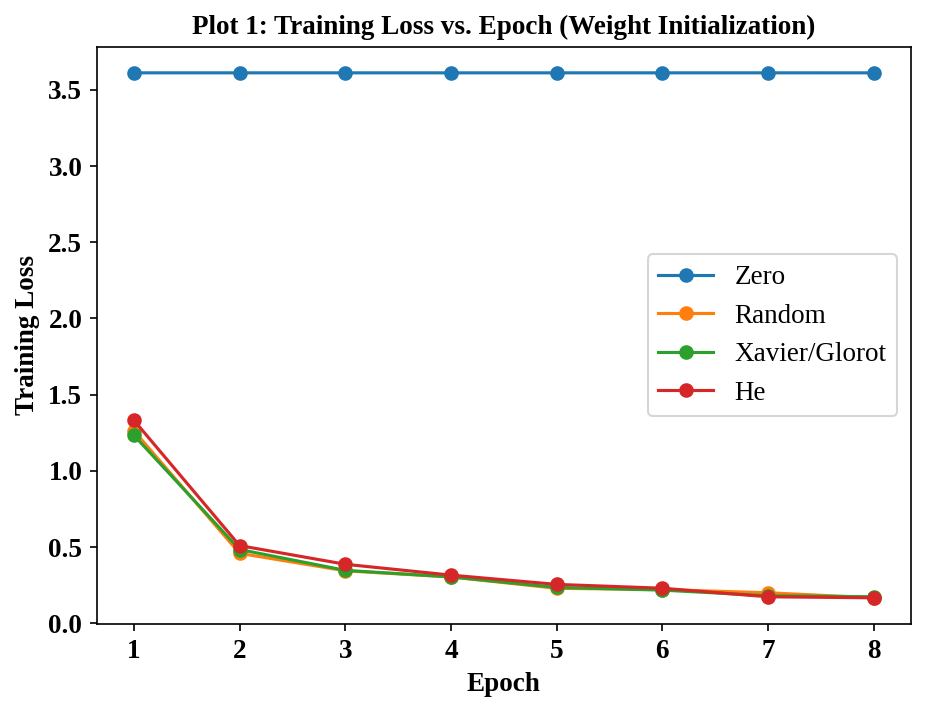

Saved: outputs/figures/plot02_val_accuracy_vs_epoch_initialization.png


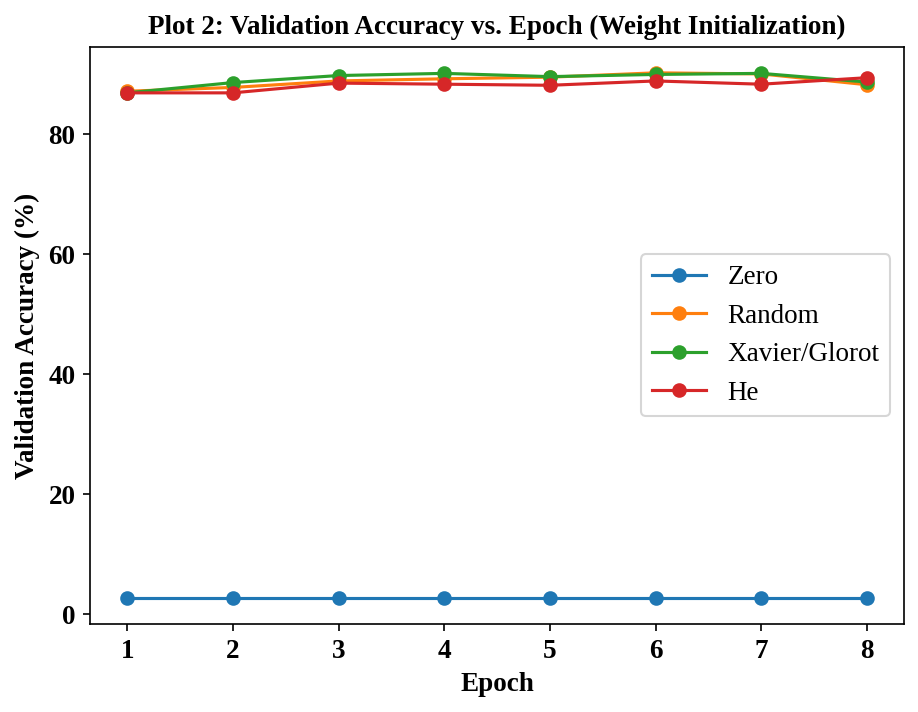

In [16]:

# Compare Zero, Random(Normal), Xavier/Glorot, He initialization.
# Only the newly-added classifier head's initializer is varied (base is pretrained ImageNet weights, frozen).
EPOCHS_INIT = 8
init_schemes = {
    "Zero": keras.initializers.Zeros(),
    "Random": keras.initializers.RandomNormal(mean=0.0, stddev=0.05, seed=SEED),
    "Xavier/Glorot": keras.initializers.GlorotUniform(seed=SEED),
    "He": keras.initializers.HeNormal(seed=SEED),
}

init_histories = {}
for name, init in init_schemes.items():
    print(f"\n=== Training with {name} initialization ===")
    # Clear and rebuild the disk cache fresh for every single iteration. Reusing one shared cache
    # across all 4 runs means the very first .fit() call must finish writing the whole cache file --
    # if that run is interrupted or OOMs partway through, the cache file is left in a corrupt/partial
    # state and every subsequent run reading from it can crash too. Rebuilding per-iteration keeps
    # each run isolated and self-contained.
    clear_disk_cache()
    t_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True,
                         cache_path="/kaggle/working/cache/train_init")
    v_ds = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val_init")

    model, base = build_mobilenetv2_model(trainable_base=False, dropout_rate=0.5,
                                           use_batchnorm=True, kernel_initializer=init)
    compile_model(model, "adam", lr=1e-3)
    hist = model.fit(t_ds, validation_data=v_ds, epochs=EPOCHS_INIT, verbose=1)
    init_histories[name] = hist.history
    reset_keras(model, base, hist, t_ds, v_ds)
    clear_disk_cache()  # cache no longer needed once this iteration's training is done

# Plot 1: Training Loss vs Epoch
fig, ax = plt.subplots(figsize=(7,5))
for name, h in init_histories.items():
    ax.plot(range(1, len(h['loss'])+1), h['loss'], marker='o', label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training Loss"); ax.set_title("Plot 1: Training Loss vs. Epoch (Weight Initialization)")
ax.legend()
style_axes(ax)
savefig(fig, "plot01_training_loss_vs_epoch_initialization.png")

# Plot 2: Validation Accuracy vs Epoch
fig, ax = plt.subplots(figsize=(7,5))
for name, h in init_histories.items():
    ax.plot(range(1, len(h['val_accuracy'])+1), [v*100 for v in h['val_accuracy']], marker='o', label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 2: Validation Accuracy vs. Epoch (Weight Initialization)")
ax.legend()
style_axes(ax)
savefig(fig, "plot02_val_accuracy_vs_epoch_initialization.png")


## 2. Regularization and Overfitting


=== Training with No Regularization ===
Cleared disk cache at /kaggle/working/cache
Epoch 1/10


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 38s 118ms/step - accuracy: 0.7928 - loss: 0.7819 - val_accuracy: 0.8691 - val_loss: 0.4267
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9258 - loss: 0.2256 - val_accuracy: 0.8881 - val_loss: 0.3414
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9557 - loss: 0.1296 - val_accuracy: 0.8818 - val_loss: 0.3610
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9710 - loss: 0.0938 - val_accuracy: 0.8998 - val_loss: 0.3449
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9832 - loss: 0.0626 - val_accuracy: 0.8917 - val_loss: 0.3531
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9849 - loss: 0.0511 - val_accuracy: 0.9007 - val_loss: 0.3508
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9936 - loss: 0.0335 - val_accuracy: 0.9043 - val_loss: 0.3443
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9969 - loss: 0.0236 - val_accuracy: 0

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 38s 119ms/step - accuracy: 0.7924 - loss: 0.9969 - val_accuracy: 0.8673 - val_loss: 0.6400
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9233 - loss: 0.4546 - val_accuracy: 0.8944 - val_loss: 0.5540
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9542 - loss: 0.3416 - val_accuracy: 0.8818 - val_loss: 0.5525
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9720 - loss: 0.2842 - val_accuracy: 0.8935 - val_loss: 0.5173
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9749 - loss: 0.2542 - val_accuracy: 0.8827 - val_loss: 0.5174
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9760 - loss: 0.2326 - val_accuracy: 0.8953 - val_loss: 0.4923
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9869 - loss: 0.1979 - val_accuracy: 0.8989 - val_loss: 0.4790
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9882 - loss: 0.1781 - val_accuracy: 

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.6163 - loss: 1.4384 - val_accuracy: 0.8691 - val_loss: 0.4458
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8455 - loss: 0.5053 - val_accuracy: 0.8908 - val_loss: 0.3493
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8848 - loss: 0.3860 - val_accuracy: 0.8872 - val_loss: 0.3306
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8964 - loss: 0.3083 - val_accuracy: 0.8971 - val_loss: 0.3248
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9138 - loss: 0.2690 - val_accuracy: 0.8962 - val_loss: 0.3330
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9292 - loss: 0.2268 - val_accuracy: 0.9034 - val_loss: 0.3081
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9320 - loss: 0.2102 - val_accuracy: 0.8962 - val_loss: 0.3178
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9389 - loss: 0.1813 - val_accuracy: 0.

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 44s 122ms/step - accuracy: 0.8038 - loss: 0.7004 - val_accuracy: 0.8800 - val_loss: 0.3961
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.9439 - loss: 0.1729 - val_accuracy: 0.8890 - val_loss: 0.3723
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9642 - loss: 0.1082 - val_accuracy: 0.8944 - val_loss: 0.3604
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9787 - loss: 0.0717 - val_accuracy: 0.8899 - val_loss: 0.3817
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9880 - loss: 0.0435 - val_accuracy: 0.8917 - val_loss: 0.3882
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9905 - loss: 0.0340 - val_accuracy: 0.8989 - val_loss: 0.3832
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9925 - loss: 0.0252 - val_accuracy: 0.8872 - val_loss: 0.4416
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9959 - loss: 0.0196 - val_accuracy: 0.

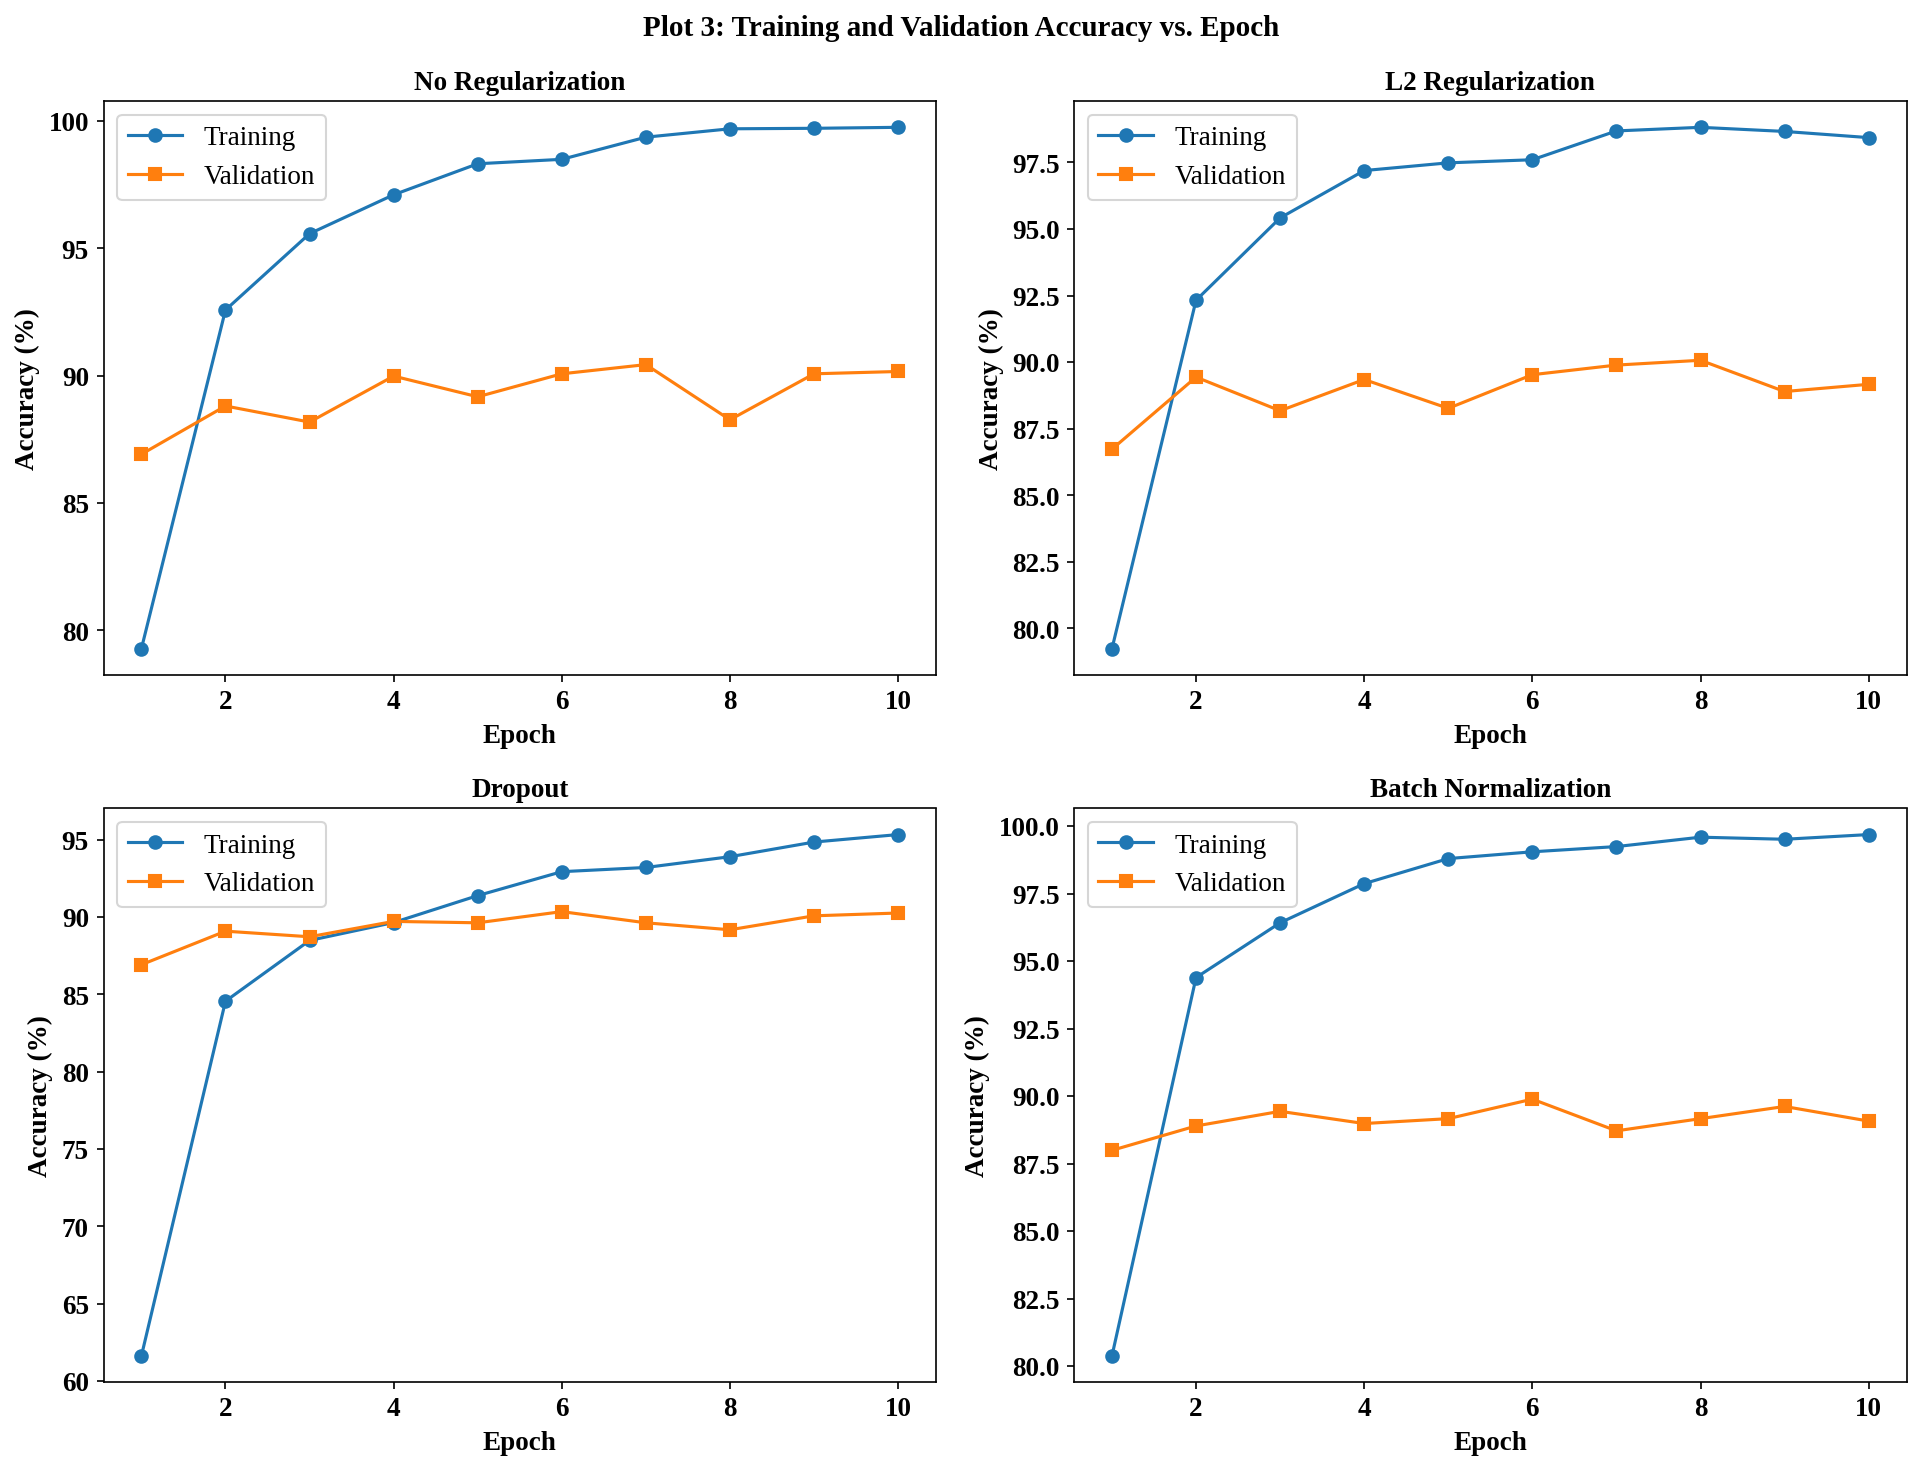

Saved: outputs/figures/plot04_train_val_loss_vs_epoch_regularization.png


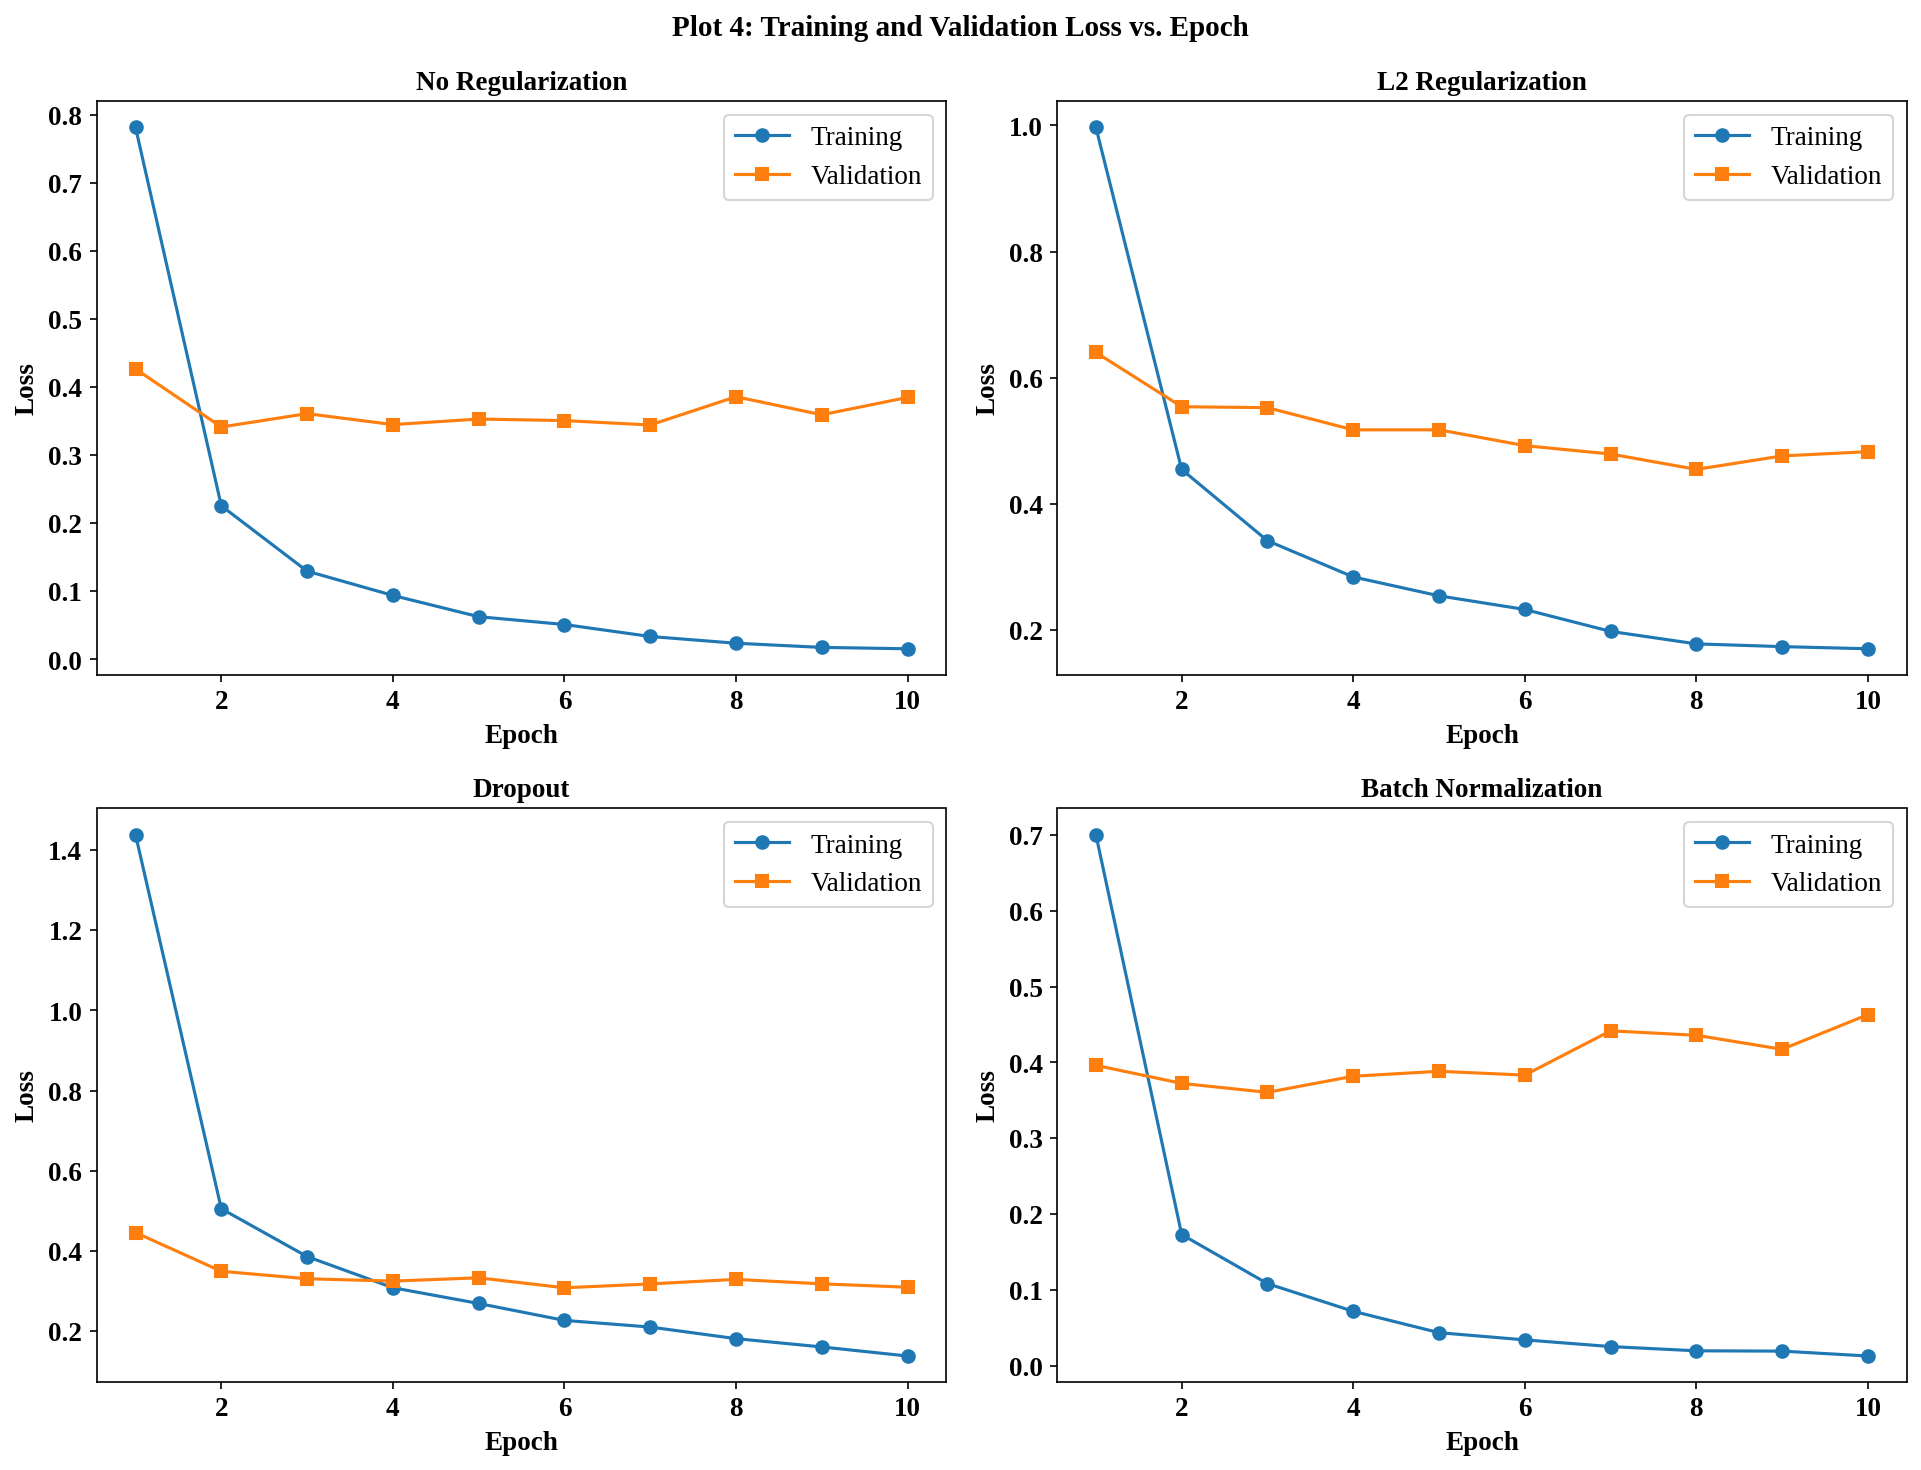

In [17]:

EPOCHS_REG = 10
reg_configs = {
    "No Regularization": dict(dropout_rate=0.0, use_batchnorm=False, l2_reg=0.0),
    "L2 Regularization":  dict(dropout_rate=0.0, use_batchnorm=False, l2_reg=1e-3),
    "Dropout":            dict(dropout_rate=0.5, use_batchnorm=False, l2_reg=0.0),
    "Batch Normalization":dict(dropout_rate=0.0, use_batchnorm=True,  l2_reg=0.0),
}

reg_histories = {}
for name, cfg in reg_configs.items():
    print(f"\n=== Training with {name} ===")
    clear_disk_cache()
    t_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True,
                         cache_path="/kaggle/working/cache/train_reg")
    v_ds = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val_reg")

    model, base = build_mobilenetv2_model(trainable_base=False, **cfg)
    compile_model(model, "adam", lr=1e-3)
    hist = model.fit(t_ds, validation_data=v_ds, epochs=EPOCHS_REG, verbose=1)
    reg_histories[name] = hist.history
    reset_keras(model, base, hist, t_ds, v_ds)
    clear_disk_cache()

# Plot 3: Training & Validation Accuracy vs Epoch (all configs, one subplot each)
fig, axes = plt.subplots(2, 2, figsize=(13,10))
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    epochs_r = range(1, len(h['accuracy'])+1)
    ax.plot(epochs_r, [v*100 for v in h['accuracy']], marker='o', label='Training')
    ax.plot(epochs_r, [v*100 for v in h['val_accuracy']], marker='s', label='Validation')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)"); ax.set_title(name)
    ax.legend()
    style_axes(ax)
fig.suptitle("Plot 3: Training and Validation Accuracy vs. Epoch", fontweight='bold', fontsize=14, fontname=FONT_NAME)
fig.tight_layout()
savefig(fig, "plot03_train_val_accuracy_vs_epoch_regularization.png")

# Plot 4: Training & Validation Loss vs Epoch
fig, axes = plt.subplots(2, 2, figsize=(13,10))
for ax, (name, h) in zip(axes.flat, reg_histories.items()):
    epochs_r = range(1, len(h['loss'])+1)
    ax.plot(epochs_r, h['loss'], marker='o', label='Training')
    ax.plot(epochs_r, h['val_loss'], marker='s', label='Validation')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title(name)
    ax.legend()
    style_axes(ax)
fig.suptitle("Plot 4: Training and Validation Loss vs. Epoch", fontweight='bold', fontsize=14, fontname=FONT_NAME)
fig.tight_layout()
savefig(fig, "plot04_train_val_loss_vs_epoch_regularization.png")


## 3. Batch Normalization

Cleared disk cache at /kaggle/working/cache
Epoch 1/10


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 120ms/step - accuracy: 0.6629 - loss: 1.2199 - val_accuracy: 0.8655 - val_loss: 0.4565
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8562 - loss: 0.4697 - val_accuracy: 0.8836 - val_loss: 0.3671
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8823 - loss: 0.3780 - val_accuracy: 0.8953 - val_loss: 0.3344
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9084 - loss: 0.2811 - val_accuracy: 0.8944 - val_loss: 0.3658
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9194 - loss: 0.2345 - val_accuracy: 0.8890 - val_loss: 0.3675
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9312 - loss: 0.2017 - val_accuracy: 0.8953 - val_loss: 0.3750
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9339 - loss: 0.1885 - val_accuracy: 0.8953 - val_loss: 0.3613
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9356 - loss: 0.1866 - val_accuracy: 0.

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 122ms/step - accuracy: 0.6138 - loss: 1.4340 - val_accuracy: 0.8818 - val_loss: 0.4285
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8521 - loss: 0.4902 - val_accuracy: 0.8782 - val_loss: 0.3577
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.8838 - loss: 0.3747 - val_accuracy: 0.8917 - val_loss: 0.3294
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8946 - loss: 0.3195 - val_accuracy: 0.8926 - val_loss: 0.3177
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9136 - loss: 0.2644 - val_accuracy: 0.8980 - val_loss: 0.3186
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9248 - loss: 0.2261 - val_accuracy: 0.9034 - val_loss: 0.3058
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9335 - loss: 0.2110 - val_accuracy: 0.9052 - val_loss: 0.3199
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9410 - loss: 0.1755 - val_accuracy:

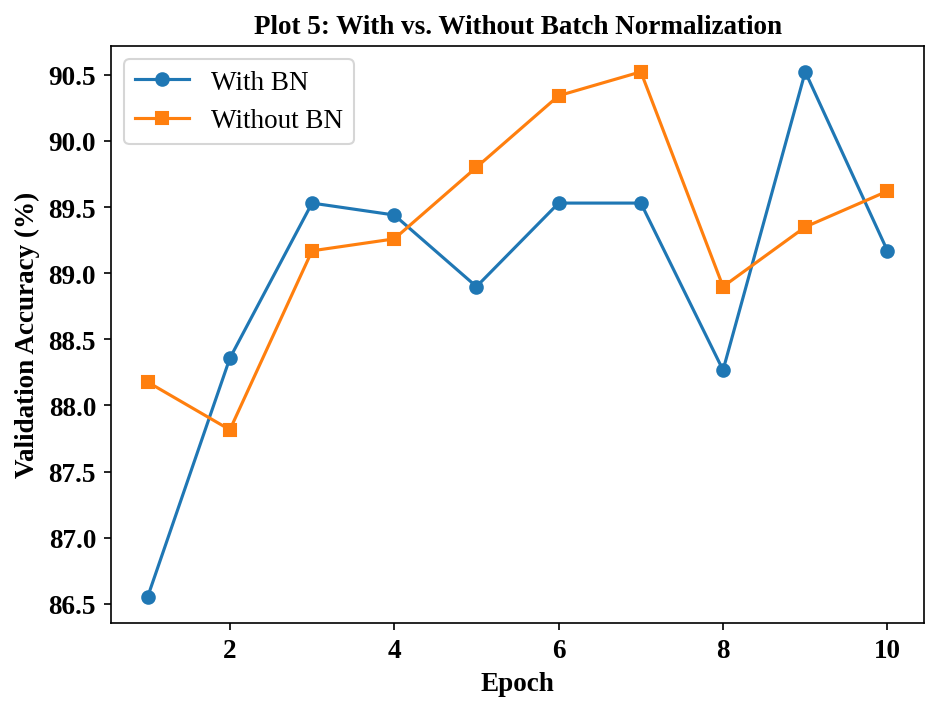

In [18]:

# With vs Without Batch Normalization — model comparison
EPOCHS_BN = 10

clear_disk_cache()
t_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True,
                     cache_path="/kaggle/working/cache/train_bn")
v_ds = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val_bn")

model_bn, base_bn = build_mobilenetv2_model(trainable_base=False, dropout_rate=0.5, use_batchnorm=True)
compile_model(model_bn, "adam", lr=1e-3)
hist_bn = model_bn.fit(t_ds, validation_data=v_ds, epochs=EPOCHS_BN, verbose=1)
hist_bn = hist_bn.history  # keep only the plain dict; release the model/callback object
reset_keras(model_bn, base_bn)
clear_disk_cache()

t_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True,
                     cache_path="/kaggle/working/cache/train_nobn")
v_ds = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val_nobn")

model_nobn, base_nobn = build_mobilenetv2_model(trainable_base=False, dropout_rate=0.5, use_batchnorm=False)
compile_model(model_nobn, "adam", lr=1e-3)
hist_nobn = model_nobn.fit(t_ds, validation_data=v_ds, epochs=EPOCHS_BN, verbose=1)
hist_nobn = hist_nobn.history
reset_keras(model_nobn, base_nobn, t_ds, v_ds)
clear_disk_cache()

# Plot 5: With vs Without BN
fig, ax = plt.subplots(figsize=(7,5))
ep = range(1, EPOCHS_BN+1)
ax.plot(ep, [v*100 for v in hist_bn['val_accuracy']], marker='o', label='With BN')
ax.plot(ep, [v*100 for v in hist_nobn['val_accuracy']], marker='s', label='Without BN')
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 5: With vs. Without Batch Normalization")
ax.legend()
style_axes(ax)
savefig(fig, "plot05_with_vs_without_bn.png")


## 4. Optimization Algorithms


=== Training with optimizer: SGD ===
Cleared disk cache at /kaggle/working/cache
Epoch 1/10


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 49s 120ms/step - accuracy: 0.0479 - loss: 4.3787 - val_accuracy: 0.1273 - val_loss: 3.2556
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.1235 - loss: 3.5311 - val_accuracy: 0.3357 - val_loss: 2.6049
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.2190 - loss: 2.9088 - val_accuracy: 0.4856 - val_loss: 2.0812
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.3277 - loss: 2.4598 - val_accuracy: 0.5966 - val_loss: 1.7033
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.3961 - loss: 2.1458 - val_accuracy: 0.6814 - val_loss: 1.4338
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.4663 - loss: 1.8867 - val_accuracy: 0.7184 - val_loss: 1.2332
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5223 - loss: 1.7049 - val_accuracy: 0.7536 - val_loss: 1.0841
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5647 - loss: 1.5469 - val_accuracy: 0

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step - accuracy: 0.3458 - loss: 2.6087 - val_accuracy: 0.8032 - val_loss: 1.0775
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7060 - loss: 1.0410 - val_accuracy: 0.8466 - val_loss: 0.5268
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.7827 - loss: 0.7406 - val_accuracy: 0.8655 - val_loss: 0.4245
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8109 - loss: 0.6287 - val_accuracy: 0.8745 - val_loss: 0.3898
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8399 - loss: 0.5217 - val_accuracy: 0.8745 - val_loss: 0.3668
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8513 - loss: 0.4795 - val_accuracy: 0.8881 - val_loss: 0.3489
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.8693 - loss: 0.4296 - val_accuracy: 0.8854 - val_loss: 0.3424
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8747 - loss: 0.4137 - val_accuracy: 

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.6745 - loss: 1.1744 - val_accuracy: 0.8736 - val_loss: 0.4224
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8604 - loss: 0.4627 - val_accuracy: 0.8800 - val_loss: 0.3823
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.8887 - loss: 0.3663 - val_accuracy: 0.8809 - val_loss: 0.3812
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9101 - loss: 0.2885 - val_accuracy: 0.8935 - val_loss: 0.4050
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9231 - loss: 0.2443 - val_accuracy: 0.8872 - val_loss: 0.4533
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9223 - loss: 0.2391 - val_accuracy: 0.8890 - val_loss: 0.4477
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9372 - loss: 0.2112 - val_accuracy: 0.8944 - val_loss: 0.4705
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9408 - loss: 0.1984 - val_accuracy: 

Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 40s 123ms/step - accuracy: 0.6646 - loss: 1.2450 - val_accuracy: 0.8718 - val_loss: 0.4342
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8531 - loss: 0.4740 - val_accuracy: 0.8791 - val_loss: 0.3890
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.8912 - loss: 0.3424 - val_accuracy: 0.8827 - val_loss: 0.3472
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.9080 - loss: 0.2839 - val_accuracy: 0.8881 - val_loss: 0.3646
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9117 - loss: 0.2621 - val_accuracy: 0.8899 - val_loss: 0.4129
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9260 - loss: 0.2244 - val_accuracy: 0.8908 - val_loss: 0.3823
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9383 - loss: 0.1817 - val_accuracy: 0.8989 - val_loss: 0.3939
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9457 - loss: 0.1654 - val_accuracy: 

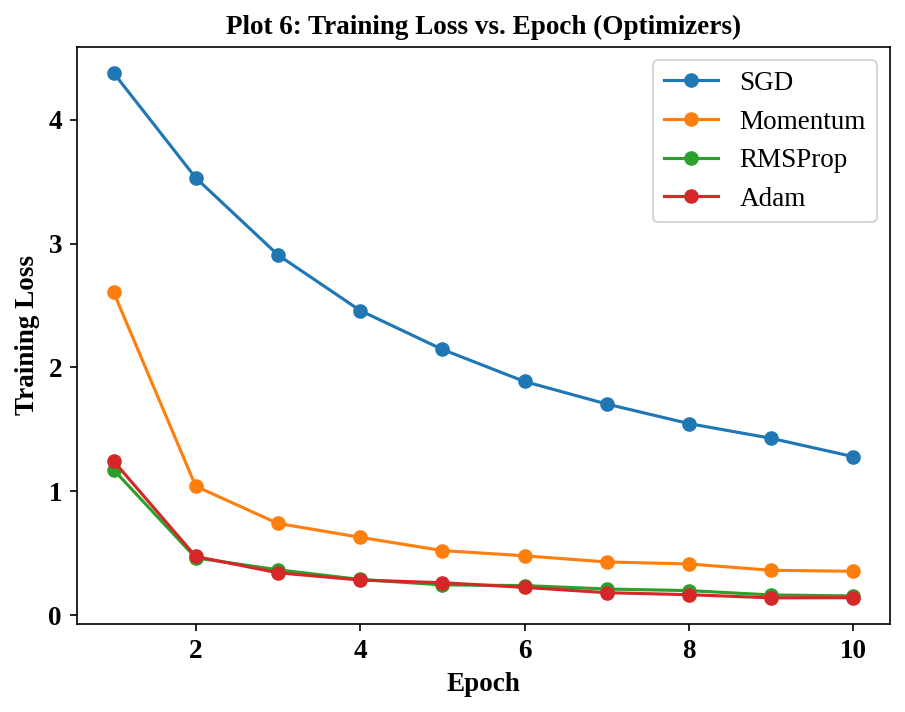

Saved: outputs/figures/plot07_val_accuracy_vs_epoch_optimizers.png


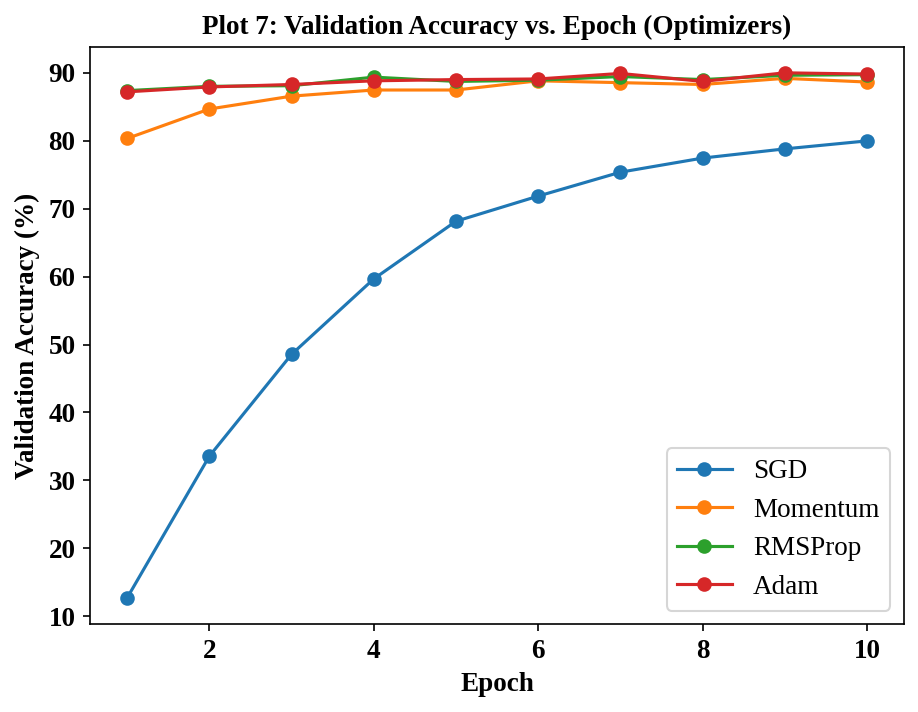

Cleared disk cache at /kaggle/working/cache


In [19]:

EPOCHS_OPT = 10
optimizer_names = ["sgd", "momentum", "rmsprop", "adam"]
opt_display = {"sgd": "SGD", "momentum": "Momentum", "rmsprop": "RMSProp", "adam": "Adam"}

opt_histories = {}
opt_summary_rows = []
for opt_name in optimizer_names:
    print(f"\n=== Training with optimizer: {opt_display[opt_name]} ===")
    clear_disk_cache()
    t_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True,
                         cache_path="/kaggle/working/cache/train_opt")
    v_ds = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val_opt")

    model, base = build_mobilenetv2_model(trainable_base=False, dropout_rate=0.5, use_batchnorm=True)
    compile_model(model, opt_name, lr=1e-3)
    t0 = time.time()
    hist = model.fit(t_ds, validation_data=v_ds, epochs=EPOCHS_OPT, verbose=1)
    elapsed = time.time() - t0
    opt_histories[opt_display[opt_name]] = hist.history

    best_val_acc = max(hist.history['val_accuracy'])
    epoch_to_converge = int(np.argmax(hist.history['val_accuracy'])) + 1
    final_loss = hist.history['loss'][-1]
    opt_summary_rows.append({
        "Optimizer": opt_display[opt_name],
        "Final Loss": round(final_loss, 4),
        "Best Val. Accuracy": round(best_val_acc*100, 2),
        "Epoch to Converge": epoch_to_converge,
        "Time (s)": round(elapsed, 1)
    })
    reset_keras(model, base, hist, t_ds, v_ds)
    clear_disk_cache()

optimizer_summary_df = pd.DataFrame(opt_summary_rows)
optimizer_summary_df.to_csv("outputs/optimizer_summary.csv", index=False)
print(optimizer_summary_df)

# Plot 6: Training Loss vs Epoch (optimizers)
fig, ax = plt.subplots(figsize=(7,5))
for name, h in opt_histories.items():
    ax.plot(range(1, len(h['loss'])+1), h['loss'], marker='o', label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Training Loss"); ax.set_title("Plot 6: Training Loss vs. Epoch (Optimizers)")
ax.legend()
style_axes(ax)
savefig(fig, "plot06_training_loss_vs_epoch_optimizers.png")

# Plot 7: Validation Accuracy vs Epoch (optimizers)
fig, ax = plt.subplots(figsize=(7,5))
for name, h in opt_histories.items():
    ax.plot(range(1, len(h['val_accuracy'])+1), [v*100 for v in h['val_accuracy']], marker='o', label=name)
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 7: Validation Accuracy vs. Epoch (Optimizers)")
ax.legend()
style_axes(ax)
savefig(fig, "plot07_val_accuracy_vs_epoch_optimizers.png")

# Sections 1-4 are done reusing the cached train_ds/val_ds at this point (Section 5's sweep below
# builds its own uncached datasets per hyperparameter value, and Section 6 will rebuild a fresh
# cache once it starts). Clear the disk cache now to free up disk space before moving on.
clear_disk_cache()


## 5. CNN Hyperparameter Tuning

Training LR=0.001


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


  Best Val Acc: 90.70%
Training LR=0.0001


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


  Best Val Acc: 89.17%
Training Batch Size=16


...

  Best Val Acc: 89.62%
Training Dropout=0.25


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


  Best Val Acc: 90.25%
Training Dropout=0.5


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


  Best Val Acc: 89.62%

BEST HYPERPARAMETERS FOUND (from independent sweeps)
Best Learning Rate : 0.001  (Val Acc: 90.70%)
Best Batch Size     : 32  (Val Acc: 90.34%)
Best Dropout Rate   : 0.25  (Val Acc: 90.25%)
Saved: outputs/figures/plot08_lr_vs_val_accuracy.png


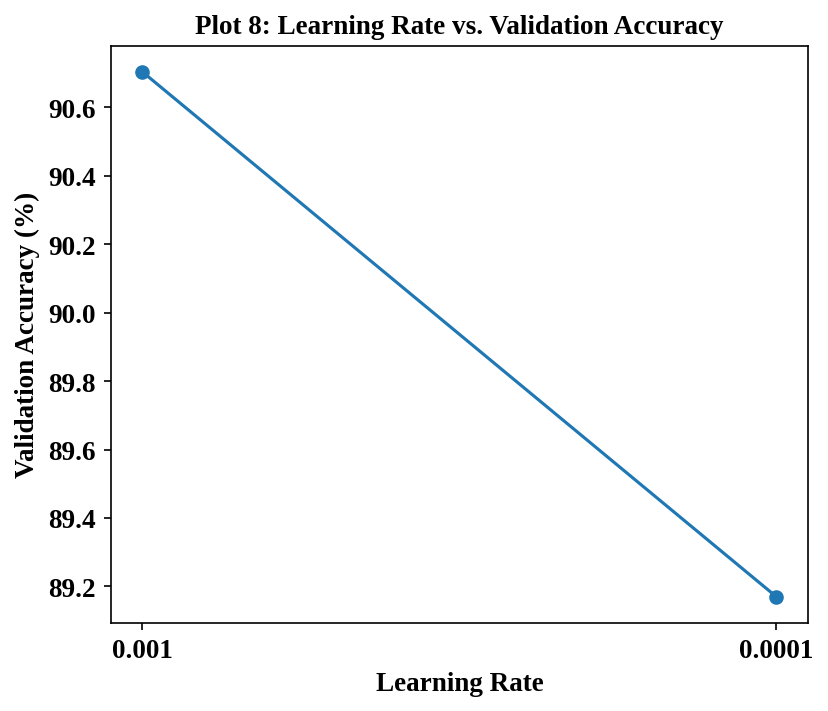

Saved: outputs/figures/plot09_batchsize_vs_val_accuracy.png


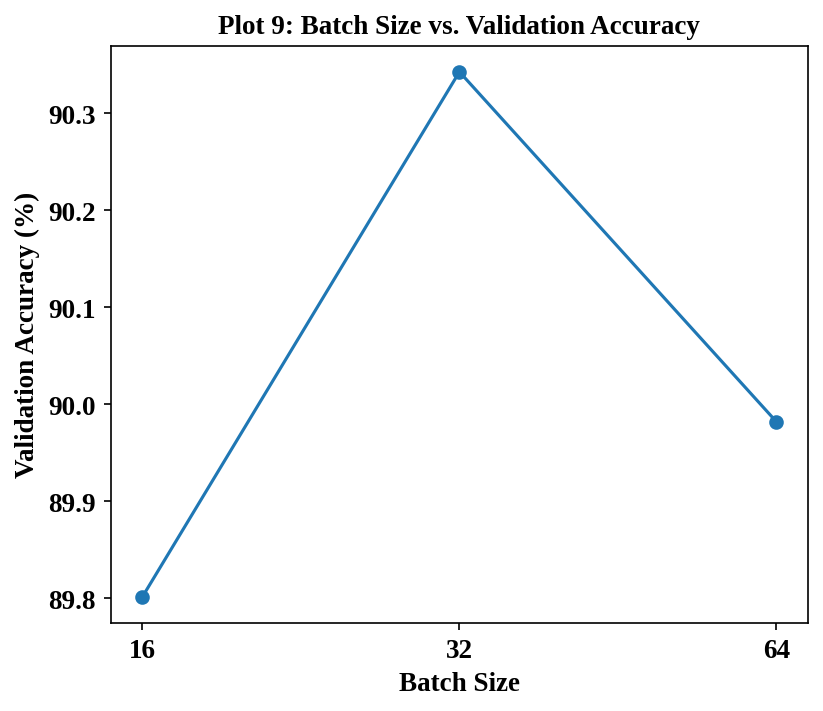

Saved: outputs/figures/plot10_dropout_vs_val_accuracy.png


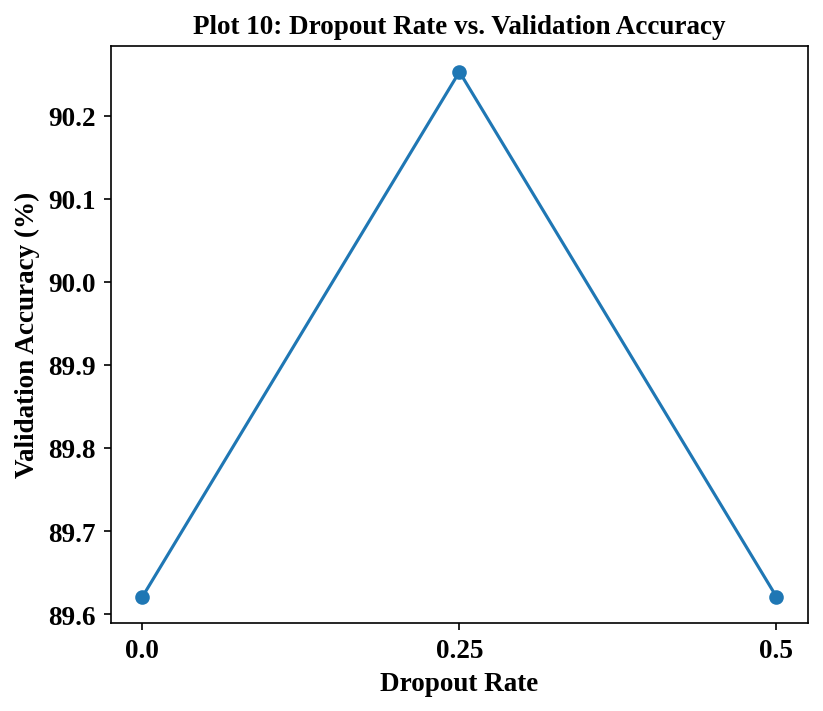


Example: N=224, K=3, P=1, S=1 -> O = 224
Example: N=224, K=3, P=0, S=2 -> O = 111


In [20]:

# Experimental rule: change ONE hyperparameter at a time, keep the rest fixed at these defaults.
DEFAULT_LR = 1e-3
DEFAULT_BATCH = 32
DEFAULT_DROPOUT = 0.25
EPOCHS_HP = 6

def train_and_get_best_val_acc(lr=DEFAULT_LR, batch_size=DEFAULT_BATCH, dropout_rate=DEFAULT_DROPOUT,
                                optimizer="adam", epochs=EPOCHS_HP):
    t_ds = make_dataset(train_df, batch_size=batch_size, shuffle=True, augment=True, cache=False)
    v_ds = make_dataset(val_df, batch_size=batch_size, cache=False)
    model, base = build_mobilenetv2_model(trainable_base=False, dropout_rate=dropout_rate, use_batchnorm=True)
    compile_model(model, optimizer, lr=lr)
    hist = model.fit(t_ds, validation_data=v_ds, epochs=epochs, verbose=0)
    best_acc = max(hist.history['val_accuracy'])
    history_dict = hist.history
    reset_keras(model, base, hist, t_ds, v_ds)
    return best_acc, history_dict

# --- Learning Rate sweep ---
lr_values = [0.001, 0.0001]
lr_results = {}
for lr in lr_values:
    print(f"Training LR={lr}")
    acc, _ = train_and_get_best_val_acc(lr=lr)
    lr_results[lr] = acc*100
    print(f"  Best Val Acc: {acc*100:.2f}%")

# --- Batch Size sweep ---
batch_values = [16, 32, 64]
batch_results = {}
for bs in batch_values:
    print(f"Training Batch Size={bs}")
    acc, _ = train_and_get_best_val_acc(batch_size=bs)
    batch_results[bs] = acc*100
    print(f"  Best Val Acc: {acc*100:.2f}%")

# --- Dropout Rate sweep ---
dropout_values = [0.0, 0.25, 0.5]
dropout_results = {}
for dr in dropout_values:
    print(f"Training Dropout={dr}")
    acc, _ = train_and_get_best_val_acc(dropout_rate=dr)
    dropout_results[dr] = acc*100
    print(f"  Best Val Acc: {acc*100:.2f}%")

hp_sweep_results = {"learning_rate": lr_results, "batch_size": batch_results, "dropout_rate": dropout_results}
with open("outputs/hp_sweep_results.json", "w") as f:
    json.dump(hp_sweep_results, f, indent=2, default=str)

# Best hyperparameters found from each independent sweep (one-at-a-time, as required by the manual)
best_lr = max(lr_results, key=lr_results.get)
best_batch_size = max(batch_results, key=batch_results.get)
best_dropout = max(dropout_results, key=dropout_results.get)

print("\n" + "="*50)
print("BEST HYPERPARAMETERS FOUND (from independent sweeps)")
print("="*50)
print(f"Best Learning Rate : {best_lr}  (Val Acc: {lr_results[best_lr]:.2f}%)")
print(f"Best Batch Size     : {best_batch_size}  (Val Acc: {batch_results[best_batch_size]:.2f}%)")
print(f"Best Dropout Rate   : {best_dropout}  (Val Acc: {dropout_results[best_dropout]:.2f}%)")
print("="*50)

# Plot 8: Learning Rate vs Validation Accuracy
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(list(map(str, lr_results.keys())), list(lr_results.values()), marker='o')
ax.set_xlabel("Learning Rate"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 8: Learning Rate vs. Validation Accuracy")
style_axes(ax)
savefig(fig, "plot08_lr_vs_val_accuracy.png")

# Plot 9: Batch Size vs Validation Accuracy
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(list(map(str, batch_results.keys())), list(batch_results.values()), marker='o')
ax.set_xlabel("Batch Size"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 9: Batch Size vs. Validation Accuracy")
style_axes(ax)
savefig(fig, "plot09_batchsize_vs_val_accuracy.png")

# Plot 10: Dropout Rate vs Validation Accuracy
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(list(map(str, dropout_results.keys())), list(dropout_results.values()), marker='o')
ax.set_xlabel("Dropout Rate"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 10: Dropout Rate vs. Validation Accuracy")
style_axes(ax)
savefig(fig, "plot10_dropout_vs_val_accuracy.png")

# Convolution output-dimension formula demo: O = floor((N + 2P - K)/S) + 1
def conv_output_dim(N, K, P, S):
    return (N + 2*P - K)//S + 1

print("\nExample: N=224, K=3, P=1, S=1 -> O =", conv_output_dim(224,3,1,1))
print("Example: N=224, K=3, P=0, S=2 -> O =", conv_output_dim(224,3,0,2))


## 6. Transfer Learning and Fine-Tuning

=== Case A: Feature Extraction ===
Epoch 1/8


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 40s 121ms/step - accuracy: 0.6660 - loss: 1.2028 - val_accuracy: 0.8691 - val_loss: 0.4230
Epoch 2/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8542 - loss: 0.4695 - val_accuracy: 0.8845 - val_loss: 0.3711
Epoch 3/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.8912 - loss: 0.3389 - val_accuracy: 0.8935 - val_loss: 0.3422
Epoch 4/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9068 - loss: 0.2835 - val_accuracy: 0.9016 - val_loss: 0.3563
Epoch 5/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9188 - loss: 0.2362 - val_accuracy: 0.8917 - val_loss: 0.3823
Epoch 6/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9310 - loss: 0.2118 - val_accuracy: 0.9025 - val_loss: 0.3567
Epoch 7/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9408 - loss: 0.1717 - val_accuracy: 0.9043 - val_loss: 0.3671
Epoch 8/8
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.9408 - loss: 0.1696 - val_accuracy: 0.9061 

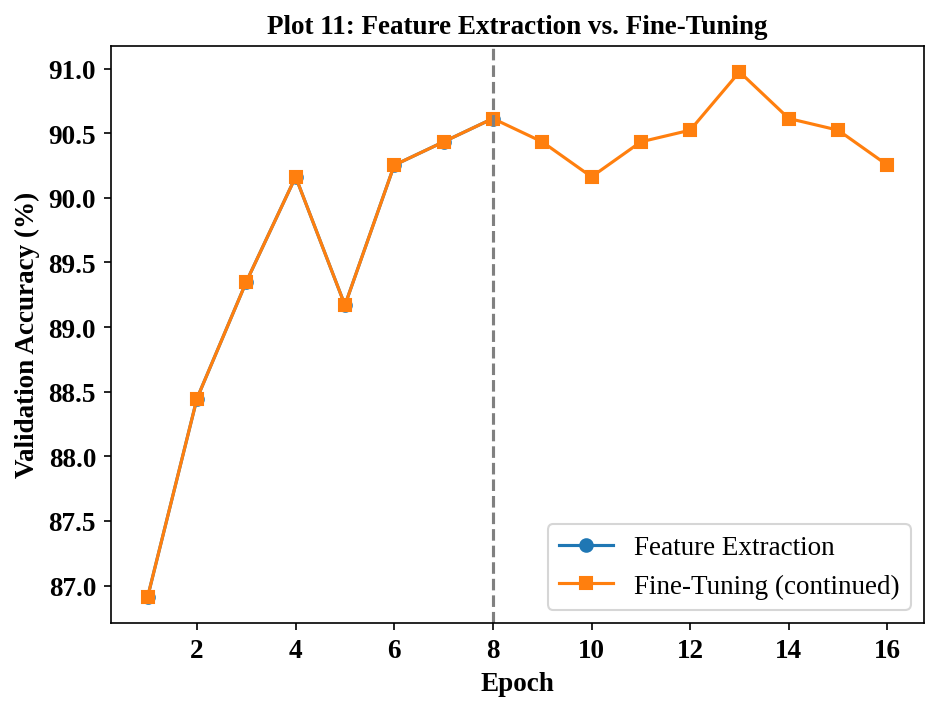

Saved: outputs/figures/plot12_loss_feature_extraction_vs_finetuning.png


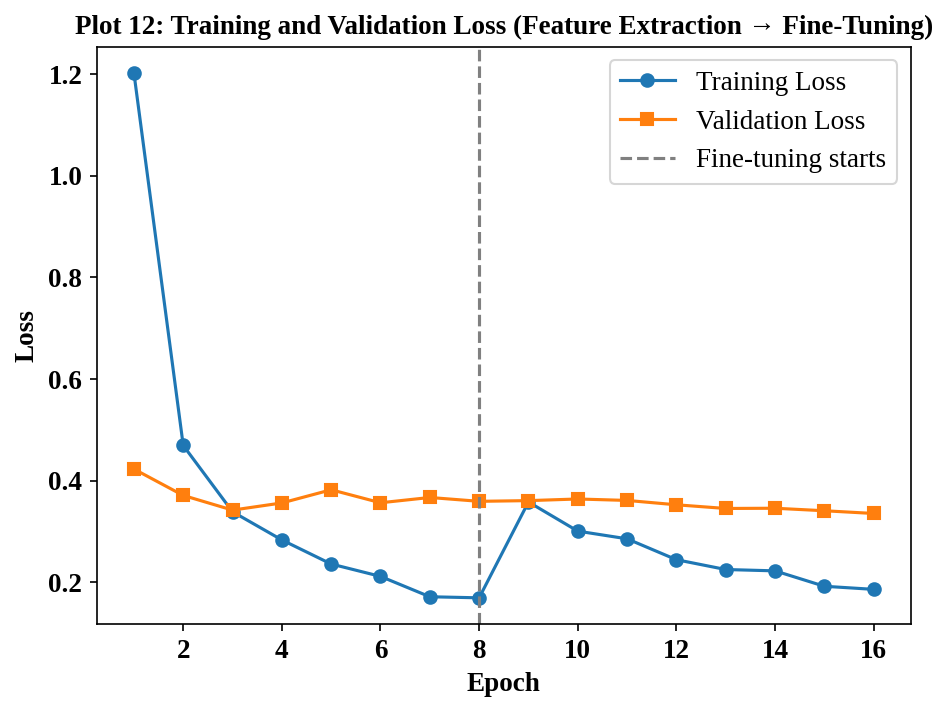

Cleared disk cache at /kaggle/working/cache


In [21]:

EPOCHS_FE = 8
EPOCHS_FT = 8

# Case A: Feature Extraction (frozen base)
print("=== Case A: Feature Extraction ===")
# Rebuild the disk cache for train_ds/val_ds since Section 5 cleared it after the optimizer/HP sweeps.
shutil.rmtree("/kaggle/working/cache", ignore_errors=True)
os.makedirs("/kaggle/working/cache", exist_ok=True)
train_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True, cache_path="/kaggle/working/cache/train")
val_ds   = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val")

model_fe, base_fe = build_mobilenetv2_model(trainable_base=False, dropout_rate=0.5, use_batchnorm=True)
compile_model(model_fe, "adam", lr=1e-3)
hist_fe = model_fe.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FE, verbose=1)
hist_fe = hist_fe.history

# Case B: Fine-Tuning (unfreeze top layers of base, small LR), continuing from feature-extraction weights
print("\n=== Case B: Fine-Tuning ===")
base_fe.trainable = True
FINE_TUNE_AT = len(base_fe.layers) - 30  # unfreeze last 30 layers
for layer in base_fe.layers[:FINE_TUNE_AT]:
    layer.trainable = False

compile_model(model_fe, "adam", lr=1e-5)  # smaller LR for fine-tuning
hist_ft = model_fe.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT, verbose=1)
hist_ft = hist_ft.history

# Combine FE + FT histories for a continuous fine-tuning curve
combined_val_acc = hist_fe['val_accuracy'] + hist_ft['val_accuracy']
combined_train_loss = hist_fe['loss'] + hist_ft['loss']
combined_val_loss = hist_fe['val_loss'] + hist_ft['val_loss']

reset_keras(model_fe, base_fe)

# Plot 11: Feature Extraction vs Fine-Tuning (Validation Accuracy)
fig, ax = plt.subplots(figsize=(7,5))
ep_fe = range(1, EPOCHS_FE+1)
ax.plot(ep_fe, [v*100 for v in hist_fe['val_accuracy']], marker='o', label='Feature Extraction')
ep_full = range(1, EPOCHS_FE+EPOCHS_FT+1)
ax.plot(ep_full, [v*100 for v in combined_val_acc], marker='s', label='Fine-Tuning (continued)')
ax.axvline(x=EPOCHS_FE, linestyle='--', color='gray')
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy (%)"); ax.set_title("Plot 11: Feature Extraction vs. Fine-Tuning")
ax.legend()
style_axes(ax)
savefig(fig, "plot11_feature_extraction_vs_finetuning.png")

# Plot 12: Training and Validation Loss (before vs after fine-tuning)
fig, ax = plt.subplots(figsize=(7,5))
ax.plot(ep_full, combined_train_loss, marker='o', label='Training Loss')
ax.plot(ep_full, combined_val_loss, marker='s', label='Validation Loss')
ax.axvline(x=EPOCHS_FE, linestyle='--', color='gray', label='Fine-tuning starts')
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.set_title("Plot 12: Training and Validation Loss (Feature Extraction \u2192 Fine-Tuning)")
ax.legend()
style_axes(ax)
savefig(fig, "plot12_loss_feature_extraction_vs_finetuning.png")

# Section 6 is done with train_ds/val_ds; K-Fold CV (Section 7) builds its own uncached per-fold
# datasets, so this cache is no longer needed until Section 8's final retrain.
clear_disk_cache()


## 7. K-Fold Cross-Validation


########## Configuration: C1_Baseline_Adam_Dropout0.5 ##########
 Fold 1/5


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


   Fold 1 Best Val Acc: 91.69%
 Fold 2/5


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


   Fold 2 Best Val Acc: 91.50%
 Fold 3/5


...

   Fold 3 Best Val Acc: 89.18%
 Fold 4/5


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


   Fold 4 Best Val Acc: 90.72%
 Fold 5/5


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


   Fold 5 Best Val Acc: 93.13%
                 Configuration     F1     F2     F3     F4     F5   Mean    SD
0  C1_Baseline_Adam_Dropout0.5  91.69  91.50  90.05  91.68  92.65  91.51  0.84
1    C2_Adam_LowLR_Dropout0.25  89.76  87.25  87.05  89.46  88.88  88.48  1.12
2     C3_RMSProp_Dropout0.5_BN  91.79  91.11  91.01  91.68  92.55  91.63  0.55
3                C4_Adam_L2Reg  91.59  90.72  89.18  90.72  93.13  91.07  1.29
Saved: outputs/figures/plot13_5fold_cv_accuracy.png


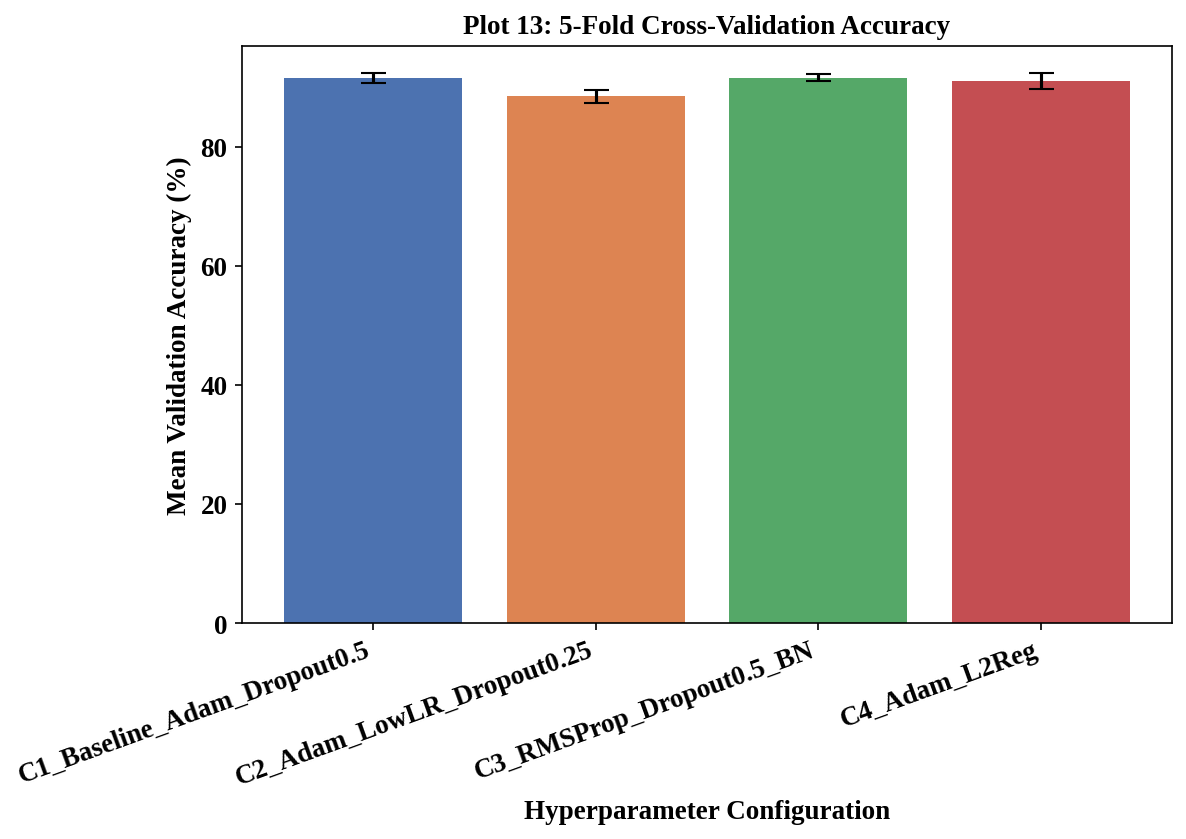

Best configuration selected via CV: C3_RMSProp_Dropout0.5_BN


In [22]:

# Select 3-4 promising configurations based on prior sections' results, then run 5-fold CV on the TRAINING data only.
K = 5
EPOCHS_CV = 5

configurations = {
    "C1_Baseline_Adam_Dropout0.5": dict(optimizer="adam", lr=1e-3, dropout_rate=0.5, use_batchnorm=True, l2_reg=0.0),
    "C2_Adam_LowLR_Dropout0.25":   dict(optimizer="adam", lr=1e-4, dropout_rate=0.25, use_batchnorm=True, l2_reg=0.0),
    "C3_RMSProp_Dropout0.5_BN":    dict(optimizer="rmsprop", lr=1e-3, dropout_rate=0.5, use_batchnorm=True, l2_reg=0.0),
    "C4_Adam_L2Reg":               dict(optimizer="adam", lr=1e-3, dropout_rate=0.0, use_batchnorm=True, l2_reg=1e-3),
}

kf = KFold(n_splits=K, shuffle=True, random_state=SEED)
train_indices = train_df.reset_index(drop=True)

cv_results = {name: [] for name in configurations}

for cfg_name, cfg in configurations.items():
    print(f"\n########## Configuration: {cfg_name} ##########")
    fold_accs = []
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(train_indices), start=1):
        print(f" Fold {fold_i}/{K}")
        fold_train_df = train_indices.iloc[tr_idx]
        fold_val_df = train_indices.iloc[va_idx]

        fold_train_ds = make_dataset(fold_train_df, shuffle=True, augment=True, cache=False)
        fold_val_ds = make_dataset(fold_val_df, cache=False)

        model, base = build_mobilenetv2_model(trainable_base=False,
                                               dropout_rate=cfg["dropout_rate"],
                                               use_batchnorm=cfg["use_batchnorm"],
                                               l2_reg=cfg["l2_reg"])
        compile_model(model, cfg["optimizer"], lr=cfg["lr"])
        hist = model.fit(fold_train_ds, validation_data=fold_val_ds, epochs=EPOCHS_CV, verbose=0)
        fold_best_acc = max(hist.history['val_accuracy'])
        fold_accs.append(fold_best_acc)
        print(f"   Fold {fold_i} Best Val Acc: {fold_best_acc*100:.2f}%")
        reset_keras(model, base, hist, fold_train_ds, fold_val_ds)
    cv_results[cfg_name] = fold_accs

# Build results table
cv_table_rows = []
for cfg_name, accs in cv_results.items():
    accs_pct = [a*100 for a in accs]
    row = {"Configuration": cfg_name}
    for i, a in enumerate(accs_pct, start=1):
        row[f"F{i}"] = round(a, 2)
    row["Mean"] = round(np.mean(accs_pct), 2)
    row["SD"] = round(np.std(accs_pct), 2)
    cv_table_rows.append(row)

cv_table = pd.DataFrame(cv_table_rows)
cv_table.to_csv("outputs/cv_results.csv", index=False)
print(cv_table)

# Plot 13: 5-Fold Cross-Validation Accuracy with SD error bars
fig, ax = plt.subplots(figsize=(8,5))
means = cv_table["Mean"].values
sds = cv_table["SD"].values
names = cv_table["Configuration"].values
x_pos = np.arange(len(names))
ax.bar(x_pos, means, yerr=sds, capsize=6, color=['#4C72B0','#DD8452','#55A868','#C44E52'][:len(names)])
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_xlabel("Hyperparameter Configuration"); ax.set_ylabel("Mean Validation Accuracy (%)")
ax.set_title("Plot 13: 5-Fold Cross-Validation Accuracy")
style_axes(ax)
savefig(fig, "plot13_5fold_cv_accuracy.png")

# Identify best configuration by mean accuracy (tie-break: lower SD)
best_cfg_name = cv_table.sort_values(by=["Mean","SD"], ascending=[False, True]).iloc[0]["Configuration"]
print("Best configuration selected via CV:", best_cfg_name)


## 8. Final Model Evaluation

In [23]:

EPOCHS_FINAL = 12

# Rebuild the disk cache for train_ds/val_ds/test_ds (cleared after Section 6; Section 7's K-Fold
# loops intentionally did not use it).
shutil.rmtree("/kaggle/working/cache", ignore_errors=True)
os.makedirs("/kaggle/working/cache", exist_ok=True)
train_ds = make_dataset(train_df, shuffle=True, augment=True, cache=True, cache_path="/kaggle/working/cache/train")
val_ds   = make_dataset(val_df, cache=True, cache_path="/kaggle/working/cache/val")
test_ds  = make_dataset(test_df, cache=True, cache_path="/kaggle/working/cache/test")

best_cfg = configurations[best_cfg_name]
print("Retraining best configuration on FULL training data:", best_cfg_name, best_cfg)

final_model, final_base = build_mobilenetv2_model(trainable_base=False,
                                                    dropout_rate=best_cfg["dropout_rate"],
                                                    use_batchnorm=best_cfg["use_batchnorm"],
                                                    l2_reg=best_cfg["l2_reg"])
compile_model(final_model, best_cfg["optimizer"], lr=best_cfg["lr"])

t0 = time.time()
final_hist = final_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINAL, verbose=1)
training_time = time.time() - t0

num_params = final_model.count_params()

# Evaluate on the untouched TEST set
y_true, y_pred = [], []
for batch_x, batch_y in test_ds:
    preds = final_model.predict(batch_x, verbose=0)
    y_true.extend(np.argmax(batch_y.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true); y_pred = np.array(y_pred)

test_accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

cv_row = cv_table[cv_table["Configuration"] == best_cfg_name].iloc[0]

final_report = {
    "Mean CV Accuracy (%)": cv_row["Mean"],
    "CV Standard Deviation": cv_row["SD"],
    "Test Accuracy (%)": round(test_accuracy*100, 2),
    "Precision (macro)": round(precision, 4),
    "Recall (macro)": round(recall, 4),
    "F1-score (macro)": round(f1, 4),
    "Training Time (s)": round(training_time, 1),
    "Number of Parameters": num_params
}
final_report_df = pd.DataFrame(list(final_report.items()), columns=["Metric", "Value"])
final_report_df.to_csv("outputs/final_model_report.csv", index=False)
print(final_report_df)

final_model.save("outputs/final_model.keras")


Retraining best configuration on FULL training data: C3_RMSProp_Dropout0.5_BN {'optimizer': 'rmsprop', 'lr': 0.001, 'dropout_rate': 0.5, 'use_batchnorm': True, 'l2_reg': 0.0}
Epoch 1/12


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 120ms/step - accuracy: 0.6816 - loss: 1.1758 - val_accuracy: 0.8881 - val_loss: 0.4025
Epoch 2/12
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8521 - loss: 0.4840 - val_accuracy: 0.8917 - val_loss: 0.3736
Epoch 3/12
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.8861 - loss: 0.3716 - val_accuracy: 0.8998 - val_loss: 0.3588
Epoch 4/12
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.9057 - loss: 0.2919 - val_accuracy: 0.8980 - val_loss: 0.3904
Epoch 5/12
162/162 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.9188 - loss: 0.2534 - val_accuracy: 0.8953 - val_loss: 0.4295
Epoch 6/12
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9275 - loss: 0.2156 - val_accuracy: 0.8890 - val_loss: 0.4334
Epoch 7/12
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9370 - loss: 0.1972 - val_accuracy: 0.8845 - val_loss: 0.4835
Epoch 8/12
162/162 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9393 - loss: 0.1862 - val_accuracy: 0

Saved: outputs/figures/plot14_confusion_matrix.png


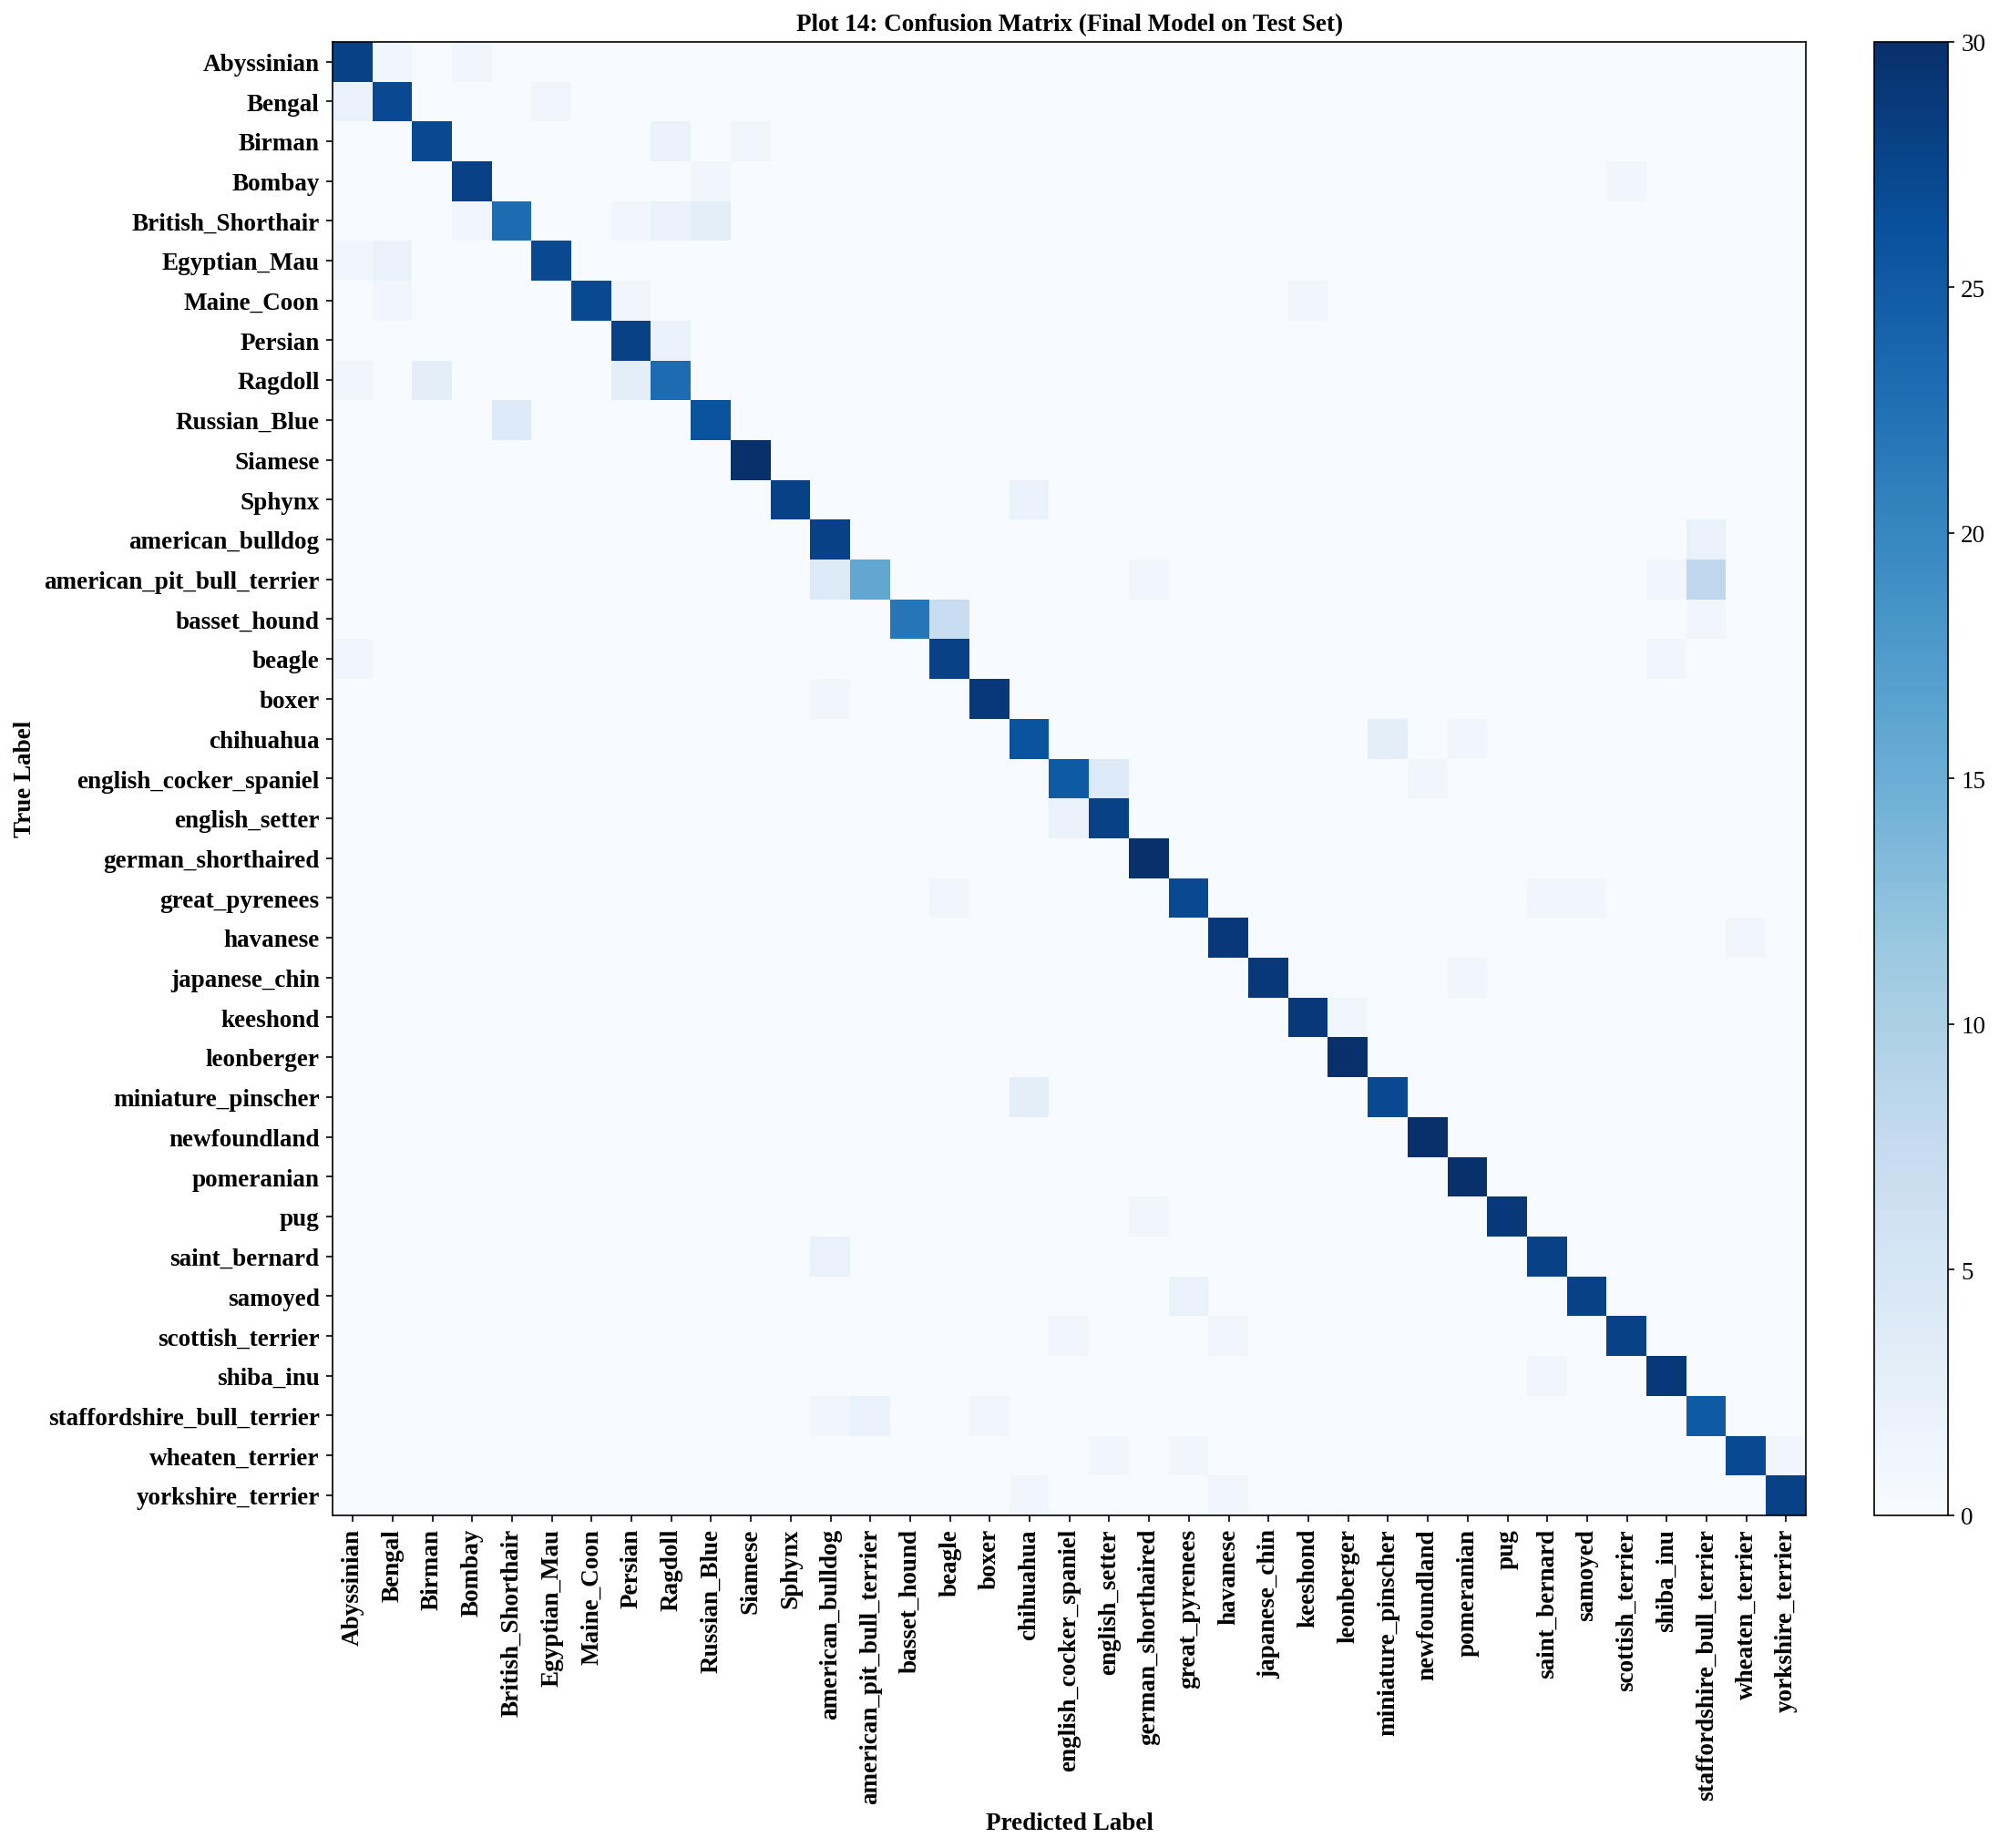

Top-5 best classified classes:
  Siamese: 100.0%
  german_shorthaired: 100.0%
  leonberger: 100.0%
  newfoundland: 100.0%
  pomeranian: 100.0%

Top confused class pairs (true -> predicted, count):
  american_pit_bull_terrier -> staffordshire_bull_terrier: 8
  basset_hound -> beagle: 7
  Russian_Blue -> British_Shorthair: 4
  english_cocker_spaniel -> english_setter: 4
  american_pit_bull_terrier -> american_bulldog: 4


In [24]:

# Plot 14: Confusion Matrix (final model, test set)
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(16,14))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(np.arange(NUM_CLASSES)); ax.set_yticks(np.arange(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
ax.set_yticklabels(CLASS_NAMES, fontsize=6)
ax.set_xlabel("Predicted Label"); ax.set_ylabel("True Label")
ax.set_title("Plot 14: Confusion Matrix (Final Model on Test Set)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
style_axes(ax)
savefig(fig, "plot14_confusion_matrix.png")

# Identify best-classified and most-confused class pairs
per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
best_classes_idx = np.argsort(per_class_acc)[::-1][:5]
print("Top-5 best classified classes:")
for idx in best_classes_idx:
    print(f"  {CLASS_NAMES[idx]}: {per_class_acc[idx]*100:.1f}%")

cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)
confused_pairs = []
flat_idx = np.dstack(np.unravel_index(np.argsort(cm_offdiag.ravel())[::-1][:5], cm_offdiag.shape))[0]
for i, j in flat_idx:
    if cm_offdiag[i, j] > 0:
        confused_pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], int(cm_offdiag[i, j])))
print("\nTop confused class pairs (true -> predicted, count):")
for pair in confused_pairs:
    print(f"  {pair[0]} -> {pair[1]}: {pair[2]}")


Saved: outputs/figures/plot15_misclassified_images.png


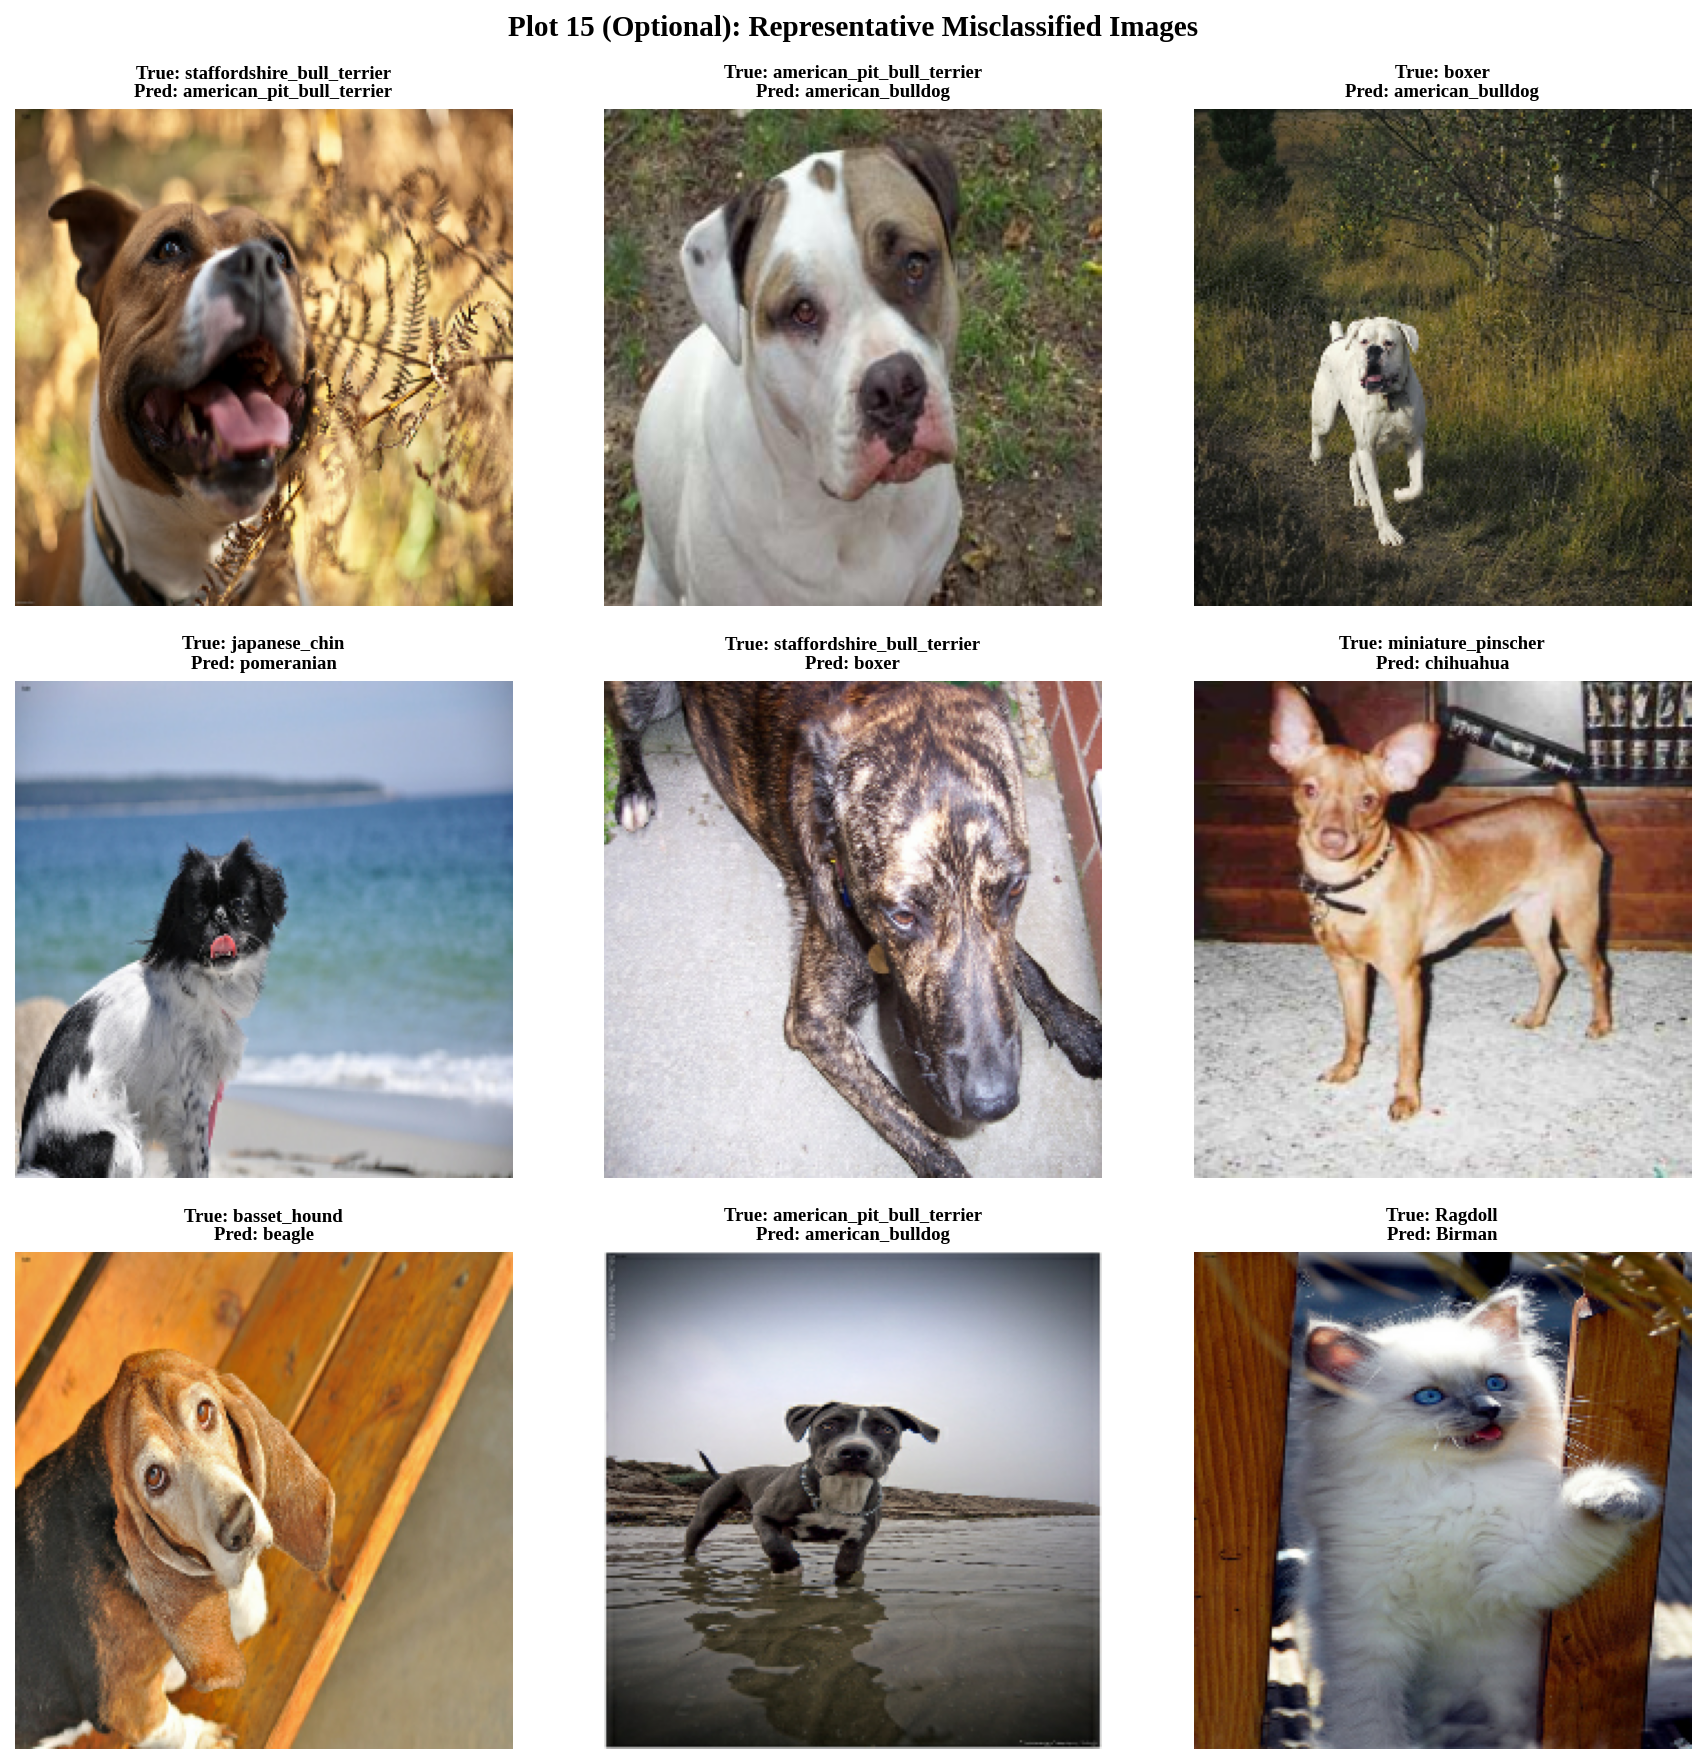

In [25]:

# Optional Plot 15: Misclassified Images (representative samples)
misclassified_idx = np.where(y_true != y_pred)[0]
n_show = min(9, len(misclassified_idx))
sample_idx = np.random.choice(misclassified_idx, size=n_show, replace=False) if n_show > 0 else []

test_paths = test_df['filepath'].values

fig, axes = plt.subplots(3, 3, figsize=(12,12))
for ax, idx in zip(axes.flat, sample_idx):
    img = tf.io.read_file(test_paths[idx])
    img = tf.image.decode_jpeg(img, channels=3, try_recover_truncated=True, acceptable_fraction=0.5)
    img = tf.image.resize(img, IMG_SIZE).numpy().astype('uint8')
    ax.imshow(img)
    ax.set_title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", fontsize=9)
    ax.axis('off')
for ax in axes.flat[len(sample_idx):]:
    ax.axis('off')
fig.suptitle("Plot 15 (Optional): Representative Misclassified Images", fontweight='bold', fontsize=14, fontname=FONT_NAME)
fig.tight_layout()
savefig(fig, "plot15_misclassified_images.png")


## 9. Overall Results Summary

In [26]:

# Consolidate results from every stage into the manual's "Overall Results" table.
baseline_val_acc = max(reg_histories["No Regularization"]['val_accuracy']) * 100
best_init_name = max(init_histories, key=lambda k: max(init_histories[k]['val_accuracy']))
best_init_acc = max(init_histories[best_init_name]['val_accuracy']) * 100
best_reg_name = max(reg_histories, key=lambda k: max(reg_histories[k]['val_accuracy']))
best_reg_acc = max(reg_histories[best_reg_name]['val_accuracy']) * 100
best_opt_row = optimizer_summary_df.sort_values("Best Val. Accuracy", ascending=False).iloc[0]
best_hp_acc = max(list(lr_results.values()) + list(batch_results.values()) + list(dropout_results.values()))
finetuned_acc = max(combined_val_acc) * 100

overall_results = pd.DataFrame([
    {"Configuration": "Baseline (No Regularization)", "Test Accuracy": f"{baseline_val_acc:.2f}% (val)"},
    {"Configuration": f"Best Initialization ({best_init_name})", "Test Accuracy": f"{best_init_acc:.2f}% (val)"},
    {"Configuration": f"Best Regularization ({best_reg_name})", "Test Accuracy": f"{best_reg_acc:.2f}% (val)"},
    {"Configuration": f"Best Optimizer ({best_opt_row['Optimizer']})", "Test Accuracy": f"{best_opt_row['Best Val. Accuracy']:.2f}% (val)"},
    {"Configuration": "Best Hyperparameters (from sweeps)", "Test Accuracy": f"{best_hp_acc:.2f}% (val)"},
    {"Configuration": "Fine-Tuned Model", "Test Accuracy": f"{finetuned_acc:.2f}% (val)"},
    {"Configuration": f"Final Selected Model ({best_cfg_name})", "Test Accuracy": f"{final_report['Test Accuracy (%)']}%"},
])
overall_results.to_csv("outputs/overall_results_summary.csv", index=False)
print(overall_results)

# CV Accuracy, SD, and Training Time apply only to the final selected model (chosen via 5-fold CV
# and retrained on the full training set) -- shown separately here rather than as mostly-empty
# columns in the table above.
print("\n" + "="*50)
print(f"FINAL SELECTED MODEL METRICS ({best_cfg_name})")
print("="*50)
print(f"Mean CV Accuracy   : {final_report['Mean CV Accuracy (%)']}%")
print(f"CV Standard Deviation: {final_report['CV Standard Deviation']}")
print(f"Training Time       : {final_report['Training Time (s)']}s")
print("="*50)


                                     Configuration Test Accuracy
0                     Baseline (No Regularization)  90.43% (val)
1                     Best Initialization (Random)  90.25% (val)
2          Best Regularization (No Regularization)  90.43% (val)
3                            Best Optimizer (Adam)  89.98% (val)
4               Best Hyperparameters (from sweeps)  90.70% (val)
5                                 Fine-Tuned Model  90.97% (val)
6  Final Selected Model (C3_RMSProp_Dropout0.5_BN)         90.8%

FINAL SELECTED MODEL METRICS (C3_RMSProp_Dropout0.5_BN)
Mean CV Accuracy   : 91.63%
CV Standard Deviation: 0.55
Training Time       : 143.3s


## 10. Additional Exercise: New Configurations via 5-Fold Cross-Validation

In [27]:

# Section 8/9 are done with train_ds/val_ds/test_ds; free that disk cache before this section's
# 10 fold trainings (2 configs x 5 folds), which build their own uncached per-fold datasets anyway.
clear_disk_cache()

# Select TWO new combinations of learning rate, dropout, batch size and fine-tuning strategy,
# evaluate with 5-fold CV, and compare against the previously selected best configuration.
EPOCHS_ADD_CV = 5

new_configurations = {
    "N1_LowLR_HighDropout_SmallBatch_FT": dict(optimizer="adam", lr=1e-4, dropout_rate=0.5,
                                                use_batchnorm=True, l2_reg=0.0, batch_size=16, fine_tune=True),
    "N2_HighLR_LowDropout_LargeBatch_FE": dict(optimizer="adam", lr=1e-3, dropout_rate=0.1,
                                                use_batchnorm=True, l2_reg=0.0, batch_size=64, fine_tune=False),
}

new_cv_results = {}
for cfg_name, cfg in new_configurations.items():
    print(f"\n########## New Configuration: {cfg_name} ##########")
    fold_accs = []
    for fold_i, (tr_idx, va_idx) in enumerate(kf.split(train_indices), start=1):
        print(f" Fold {fold_i}/{K}")
        fold_train_df = train_indices.iloc[tr_idx]
        fold_val_df = train_indices.iloc[va_idx]
        fold_train_ds = make_dataset(fold_train_df, batch_size=cfg["batch_size"], shuffle=True, augment=True, cache=False)
        fold_val_ds = make_dataset(fold_val_df, batch_size=cfg["batch_size"], cache=False)

        model, base = build_mobilenetv2_model(trainable_base=False,
                                               dropout_rate=cfg["dropout_rate"],
                                               use_batchnorm=cfg["use_batchnorm"],
                                               l2_reg=cfg["l2_reg"])
        compile_model(model, cfg["optimizer"], lr=cfg["lr"])
        model.fit(fold_train_ds, validation_data=fold_val_ds, epochs=EPOCHS_ADD_CV, verbose=0)

        if cfg["fine_tune"]:
            base.trainable = True
            for layer in base.layers[:len(base.layers)-20]:
                layer.trainable = False
            compile_model(model, cfg["optimizer"], lr=cfg["lr"]/10)
            model.fit(fold_train_ds, validation_data=fold_val_ds, epochs=3, verbose=0)

        val_eval = model.evaluate(fold_val_ds, verbose=0)
        fold_accs.append(val_eval[1])
        print(f"   Fold {fold_i} Val Acc: {val_eval[1]*100:.2f}%")
        reset_keras(model, base, fold_train_ds, fold_val_ds)
    new_cv_results[cfg_name] = fold_accs

new_cv_rows = []
for cfg_name, accs in new_cv_results.items():
    accs_pct = [a*100 for a in accs]
    row = {"Configuration": cfg_name}
    for i, a in enumerate(accs_pct, start=1):
        row[f"F{i}"] = round(a, 2)
    row["Mean"] = round(np.mean(accs_pct), 2)
    row["SD"] = round(np.std(accs_pct), 2)
    new_cv_rows.append(row)

# Append previously selected best configuration for direct comparison
prev_best_row = cv_table[cv_table["Configuration"] == best_cfg_name].to_dict(orient="records")[0]
new_cv_rows.append(prev_best_row)

comparison_table = pd.DataFrame(new_cv_rows)
comparison_table.to_csv("outputs/additional_exercise_comparison.csv", index=False)
print(comparison_table)


Cleared disk cache at /kaggle/working/cache

########## New Configuration: N1_LowLR_HighDropout_SmallBatch_FT ##########
 Fold 1/5


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


   Fold 1 Val Acc: 91.40%
 Fold 2/5


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


   Fold 2 Val Acc: 90.14%
 Fold 3/5


...

   Fold 3 Val Acc: 90.14%
 Fold 4/5


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


   Fold 4 Val Acc: 90.91%
 Fold 5/5


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment


   Fold 5 Val Acc: 92.55%
                        Configuration     F1     F2     F3     F4     F5  \
0  N1_LowLR_HighDropout_SmallBatch_FT  91.40  90.14  89.66  90.43  91.59   
1  N2_HighLR_LowDropout_LargeBatch_FE  90.72  91.21  90.14  90.91  92.55   
2            C3_RMSProp_Dropout0.5_BN  91.79  91.11  91.01  91.68  92.55   

    Mean    SD  
0  90.64  0.74  
1  91.11  0.80  
2  91.63  0.55  


Saved: outputs/figures/plot16_additional_exercise_comparison.png


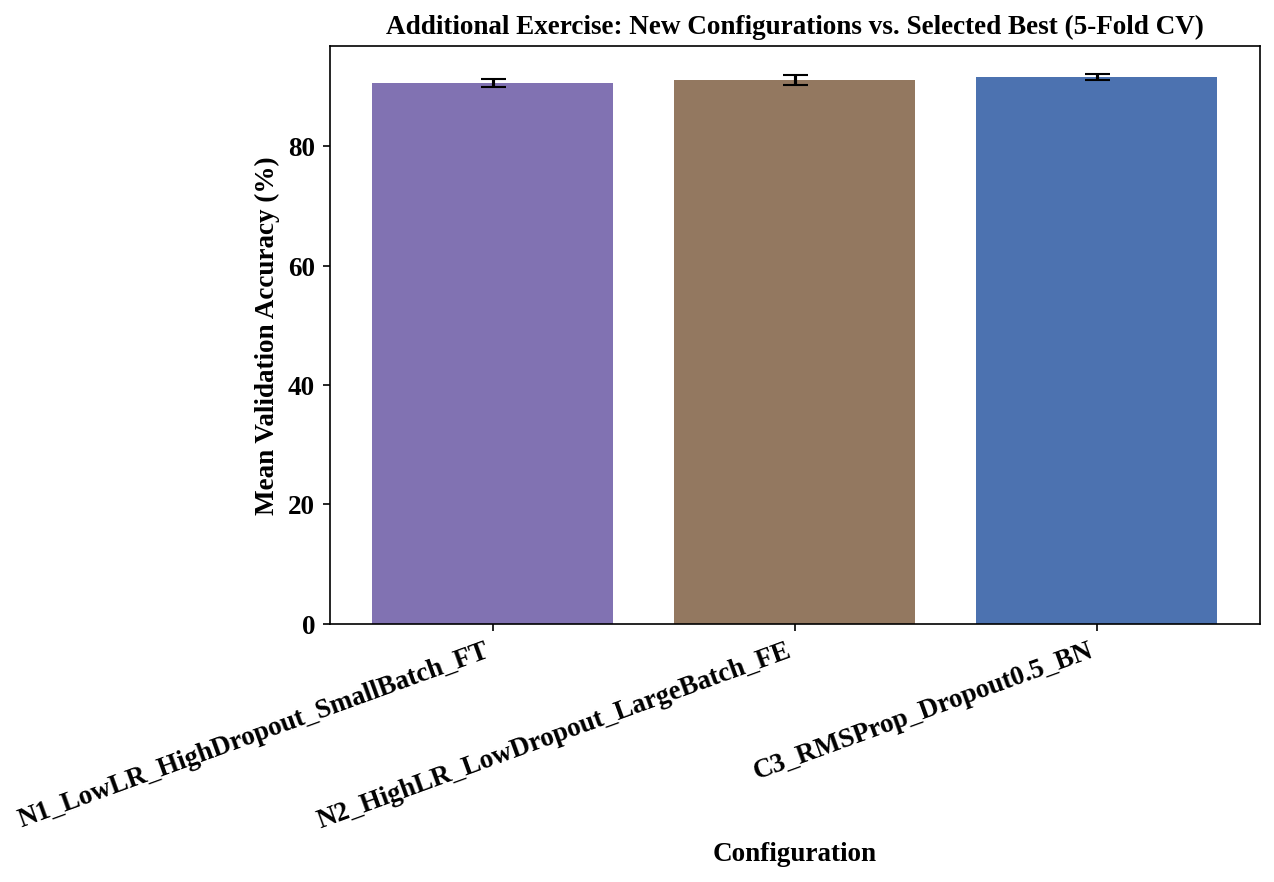

Configuration with best mean accuracy / lowest variability: C3_RMSProp_Dropout0.5_BN


In [28]:

# Comparison plot: new configurations vs previously selected best
fig, ax = plt.subplots(figsize=(8,5))
means = comparison_table["Mean"].values
sds = comparison_table["SD"].values
names = comparison_table["Configuration"].values
x_pos = np.arange(len(names))
ax.bar(x_pos, means, yerr=sds, capsize=6, color=['#8172B2','#937860','#4C72B0'][:len(names)])
ax.set_xticks(x_pos)
ax.set_xticklabels(names, rotation=20, ha='right')
ax.set_xlabel("Configuration"); ax.set_ylabel("Mean Validation Accuracy (%)")
ax.set_title("Additional Exercise: New Configurations vs. Selected Best (5-Fold CV)")
style_axes(ax)
savefig(fig, "plot16_additional_exercise_comparison.png")

winner = comparison_table.sort_values(by=["Mean","SD"], ascending=[False, True]).iloc[0]["Configuration"]
print("Configuration with best mean accuracy / lowest variability:", winner)
